# 08. Validación, testing e integración de componentes de *Invisible Dogs*

Este notebook constituye la fase intermedia entre el desarrollo experimental de los modelos y la construcción del MVP web.

Su objetivo es comprobar que los artefactos seleccionados para la aplicación pueden reutilizarse de forma **coherente, reproducible, robusta y segura**, dejando además documentados los componentes experimentales que no forman parte del runtime inicial.

Se validan siete dimensiones:

1. **Integridad e integración de artefactos**: PetID, embeddings, prototipos, fotografías y scores.
2. **Lógica del recorrido del adoptante**: filtros, búsqueda visual y búsqueda por fotografía.
3. **Funciones avanzadas de recomendación**: filtros inteligentes, modo descubrimiento y priorización por riesgo.
4. **Completitud y presentación de las fichas** mediante reglas transparentes.
5. **Componente predictivo principal de Austin**: carga, contrato de entrada, inferencia, robustez e Invisible Dog Score.
6. **Vista Protectora**: segmentación por riesgo y necesidades de presentación.
7. **Rendimiento y robustez global**: latencia, determinismo, pruebas aleatorias y casos extremos.

> Este notebook **no vuelve a entrenar los modelos ni repite todos los experimentos previos**. Reutiliza los artefactos elegidos para el MVP, valida sus contratos de consumo y determina si el sistema está preparado para pasar a la fase de aplicación.

## 0.1. Separación metodológica entre las fuentes

La aplicación mantiene una separación explícita entre los distintos componentes del TFM:

- **Austin Animal Center** continúa siendo el núcleo predictivo principal del proyecto para el riesgo de larga estancia.
- **PetFinder** permite demostrar, sobre animales con fotografía y variables estructuradas, la integración entre filtros, similitud visual y un score complementario de adopción lenta.
- **Tsinghua Dogs + DINOv2** proporcionan la capa de referencia y búsqueda visual.

Por tanto, el score de PetFinder utilizado en este notebook **no sustituye** al modelo principal de Austin. En una implantación real en una protectora, el modelo de riesgo principal se aplicaría sobre los datos de esa organización y la capa visual se integraría sobre esos mismos perros.

## 0.2. Criterios de validación

Cada prueba se clasifica con uno de los siguientes estados:

- **PASS**: prueba superada.
- **WARN**: el componente funciona, pero se detecta una circunstancia que conviene revisar.
- **FAIL**: la prueba no se supera.
- **SKIP**: prueba no ejecutada por depender de un componente desactivado o no disponible.

Las pruebas marcadas como **críticas** determinan el resultado final **GO / NO GO** para comenzar el desarrollo del MVP. Un `FAIL` crítico bloquea el paso a la aplicación. También lo hace un `SKIP` crítico, ya que una validación esencial no debería quedar sin ejecutar en la versión final del notebook.

## 0.3. Alcance de la validación y componentes fuera del runtime del MVP

Este notebook **no revalida todos los experimentos desarrollados en las fases anteriores**. Su alcance se limita a los componentes que constituyen dependencias funcionales de la primera versión del MVP y a los contratos de datos necesarios para consumirlos de forma reproducible.

En concreto:

- Del **Notebook 03**, se valida la transformación operativa de la probabilidad de Austin al **Invisible Dog Score** y sus bandas de riesgo, porque esta salida puede utilizarse en la Vista Protectora. El análisis **SHAP** conserva su valor como capa de interpretabilidad científica del modelo, pero no se recalcula en este notebook ni forma parte del runtime inicial de la aplicación.
- El **Notebook 04**, dedicado a la regresión complementaria de días de estancia, se mantiene como análisis secundario de severidad. No sustituye al clasificador principal y no forma parte de la primera versión del MVP, por lo que no se incorpora al testing de integración.
- Del **Notebook 06**, los experimentos con EfficientNet-B0, Grad-CAM y otras técnicas de interpretabilidad visual mantienen su valor analítico, pero no son dependencias del buscador final. La capa operativa de recuperación visual utiliza **DINOv2**, seleccionada y validada posteriormente para búsqueda por similitud.
- **CLIP** se conserva como referencia comparativa del análisis visual, pero no se utiliza en el ranking final del MVP, por lo que tampoco se revalida como componente de ejecución.

Esta delimitación evita confundir **experimentación científica** con **dependencias del producto**. Los componentes excluidos no se consideran descartados: quedan documentados como extensiones posibles para iteraciones posteriores.

In [1]:
from pathlib import Path
from dataclasses import dataclass, asdict
from io import BytesIO
import copy
import json
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, UnidentifiedImageError

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 220)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# Se silencian únicamente avisos cosméticos del entorno de notebooks y Hugging Face.
# No se ocultan excepciones ni warnings generados por la lógica de testing.
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TRANSFORMERS_NO_ADVISORY_WARNINGS", "1")

warnings.filterwarnings(
    "ignore",
    message=".*IProgress not found.*"
)

warnings.filterwarnings(
    "ignore",
    message=".*unauthenticated.*",
    category=UserWarning
)

try:
    from tqdm import TqdmWarning
    warnings.filterwarnings(
        "ignore",
        category=TqdmWarning
    )
except Exception:
    pass


COLOR_PRINCIPAL = "#5B2A86"
COLOR_MEDIO = "#8E67B1"
COLOR_CLARO = "#C4B5E8"
COLOR_FONDO = "#F7F4FA"
COLOR_TEXTO = "#24113F"
COLOR_BORDE = "#D8C8F2"

# Tests que cargan modelos durante el notebook.
EJECUTAR_TEST_INFERENCIA_IMAGEN = True
EJECUTAR_TEST_AUSTIN = True

# Si el kernel no contiene las librerías necesarias para deserializar
# el ensemble de Austin, el notebook puede instalarlas en el mismo
# entorno de Python de forma controlada.
INSTALAR_DEPENDENCIAS_AUSTIN_SI_FALTAN = True

# Parámetros de testing.
N_TESTS_FILTROS_ALEATORIOS = 100
N_BENCHMARK_FOTOS = 10
N_MUESTRA_AUSTIN = 512
N_BENCHMARK_AUSTIN = 10

print("Entorno de testing preparado.")

Entorno de testing preparado.


## 1. Localización reproducible del proyecto

El notebook intenta localizar automáticamente la raíz de *Invisible Dogs* a partir de la carpeta actual. También admite la variable de entorno `INVISIBLE_DOGS_PROJECT_ROOT`.

In [2]:
project_env_path = os.getenv("INVISIBLE_DOGS_PROJECT_ROOT")

candidatos_proyecto = []

if project_env_path:
    candidatos_proyecto.append(
        Path(project_env_path).expanduser()
    )

current_path = Path.cwd()

candidatos_proyecto.extend([
    current_path,
    *current_path.parents
])

# Ruta histórica utilizada durante el desarrollo del TFM.
candidatos_proyecto.append(
    Path(r"G:\Mi unidad\TFM\invisible-dogs-tfm")
)

project_path = next(
    (
        ruta
        for ruta in candidatos_proyecto
        if (ruta / "data").exists()
        and (ruta / "outputs").exists()
    ),
    None
)

if project_path is None:
    raise FileNotFoundError(
        "No se ha podido localizar la raíz del proyecto Invisible Dogs. "
        "Ejecute el notebook desde la raíz o desde notebooks, "
        "o defina INVISIBLE_DOGS_PROJECT_ROOT."
    )

project_path = project_path.resolve()

data_path = project_path / "data"
processed_data_path = data_path / "processed"
petfinder_raw_path = data_path / "raw_petfinder"

outputs_path = project_path / "outputs"
testing_outputs_path = outputs_path / "testing"
app_ready_outputs_path = outputs_path / "app_ready"

testing_outputs_path.mkdir(
    parents=True,
    exist_ok=True
)

app_ready_outputs_path.mkdir(
    parents=True,
    exist_ok=True
)

print("Ruta del proyecto:")
print(project_path)

print("\nResultados de testing:")
print(testing_outputs_path)

print("\nArtefactos preparados para la app:")
print(app_ready_outputs_path)

Ruta del proyecto:
G:\Mi unidad\TFM\invisible-dogs-tfm

Resultados de testing:
G:\Mi unidad\TFM\invisible-dogs-tfm\outputs\testing

Artefactos preparados para la app:
G:\Mi unidad\TFM\invisible-dogs-tfm\outputs\app_ready


## 2. Registro centralizado de pruebas

In [3]:
@dataclass
class ResultadoTest:
    bloque: str
    prueba: str
    estado: str
    critico: bool
    detalle: str = ""
    metrica: object = None


RESULTADOS_TEST = []


def registrar_test(
    bloque,
    prueba,
    estado,
    critico=True,
    detalle="",
    metrica=None
):
    estado = str(estado).upper()

    if estado not in {
        "PASS",
        "WARN",
        "FAIL",
        "SKIP"
    }:
        raise ValueError(
            f"Estado no válido: {estado}"
        )

    RESULTADOS_TEST.append(
        ResultadoTest(
            bloque=str(bloque),
            prueba=str(prueba),
            estado=estado,
            critico=bool(critico),
            detalle=str(detalle),
            metrica=metrica
        )
    )


def registrar_bool(
    bloque,
    prueba,
    condicion,
    critico=True,
    detalle_pass="Correcto.",
    detalle_fail="La condición no se cumple.",
    metrica=None
):
    registrar_test(
        bloque=bloque,
        prueba=prueba,
        estado="PASS" if bool(condicion) else "FAIL",
        critico=critico,
        detalle=detalle_pass if bool(condicion) else detalle_fail,
        metrica=metrica
    )


def resultados_test_df():
    if len(RESULTADOS_TEST) == 0:
        return pd.DataFrame(
            columns=[
                "bloque",
                "prueba",
                "estado",
                "critico",
                "detalle",
                "metrica"
            ]
        )

    return pd.DataFrame(
        [
            asdict(resultado)
            for resultado
            in RESULTADOS_TEST
        ]
    )


print("Registro de pruebas preparado.")

Registro de pruebas preparado.


### 2.1. Validación del entorno de ejecución de Austin

El modelo principal de Austin fue serializado como un ensemble que contiene objetos de **CatBoost** y **LightGBM**. Por tanto, esas librerías deben estar disponibles en el mismo kernel desde el que se carga el archivo `modelo_final_invisible_dogs.pkl`.

Este bloque comprueba de forma explícita las dependencias de inferencia. Si falta alguna y `INSTALAR_DEPENDENCIAS_AUSTIN_SI_FALTAN = True`, se instala únicamente la dependencia ausente mediante el mismo intérprete de Python del kernel activo. La salida de `pip` se mantiene oculta para no ensuciar el notebook y posteriormente se registran las versiones realmente utilizadas.

> Esta instalación no reentrena ningún modelo ni modifica los artefactos del TFM; únicamente prepara el entorno necesario para deserializarlos y ejecutar inferencia.

In [4]:
import importlib
import importlib.metadata
import importlib.util
import subprocess
import sys


DEPENDENCIAS_AUSTIN = {
    "catboost": "catboost",
    "lightgbm": "lightgbm",
    "joblib": "joblib",
    "sklearn": "scikit-learn"
}


def modulo_disponible(nombre_modulo):
    return importlib.util.find_spec(
        nombre_modulo
    ) is not None


faltantes_austin = [
    modulo
    for modulo
    in DEPENDENCIAS_AUSTIN
    if not modulo_disponible(modulo)
]


if (
    len(faltantes_austin) > 0
    and INSTALAR_DEPENDENCIAS_AUSTIN_SI_FALTAN
):

    paquetes_instalar = [
        DEPENDENCIAS_AUSTIN[modulo]
        for modulo
        in faltantes_austin
    ]

    print(
        "Dependencias Austin ausentes: "
        + ", ".join(faltantes_austin)
    )

    print(
        "Instalando en el kernel actual: "
        + ", ".join(paquetes_instalar)
    )

    proceso_pip = subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--disable-pip-version-check",
            *paquetes_instalar
        ],
        capture_output=True,
        text=True
    )

    importlib.invalidate_caches()

    if proceso_pip.returncode != 0:
        print(
            "La instalación automática no se ha "
            "podido completar."
        )
        print(
            proceso_pip.stderr[-1500:]
        )


faltantes_austin_final = [
    modulo
    for modulo
    in DEPENDENCIAS_AUSTIN
    if not modulo_disponible(modulo)
]

DEPENDENCIAS_AUSTIN_OK = (
    len(faltantes_austin_final) == 0
)


VERSIONES_RUNTIME_AUSTIN = {}

if DEPENDENCIAS_AUSTIN_OK:

    for modulo, paquete in (
        DEPENDENCIAS_AUSTIN.items()
    ):
        try:
            VERSIONES_RUNTIME_AUSTIN[
                modulo
            ] = importlib.metadata.version(
                paquete
            )
        except Exception:
            VERSIONES_RUNTIME_AUSTIN[
                modulo
            ] = "desconocida"


registrar_bool(
    bloque="Entorno Austin",
    prueba="Dependencias de inferencia disponibles",
    condicion=DEPENDENCIAS_AUSTIN_OK,
    critico=True,
    detalle_pass=(
        "Runtime preparado: "
        + json.dumps(
            VERSIONES_RUNTIME_AUSTIN,
            ensure_ascii=False
        )
    ),
    detalle_fail=(
        "Siguen faltando: "
        + str(faltantes_austin_final)
    )
)


print(
    "Runtime Austin preparado:",
    DEPENDENCIAS_AUSTIN_OK
)

if DEPENDENCIAS_AUSTIN_OK:
    display(
        pd.DataFrame(
            [
                {
                    "libreria": modulo,
                    "version": version
                }
                for modulo, version
                in VERSIONES_RUNTIME_AUSTIN.items()
            ]
        )
    )

Runtime Austin preparado: True


,libreria,version
0,catboost,1.2.10
1,lightgbm,4.7.0
2,joblib,1.5.3
3,sklearn,1.9.0


## 3. Inventario de artefactos

Primero se comprueba que existen los elementos generados en los notebooks anteriores y necesarios para la futura aplicación.

In [5]:
def localizar_archivo(
    nombre,
    carpetas
):
    for carpeta in carpetas:
        carpeta = Path(carpeta)

        if not carpeta.exists():
            continue

        ruta_directa = carpeta / nombre

        if ruta_directa.exists():
            return ruta_directa

        candidatos = list(
            carpeta.rglob(nombre)
        )

        if len(candidatos) > 0:
            return sorted(
                candidatos,
                key=lambda ruta: len(str(ruta))
            )[0]

    return None


def localizar_csv_por_columnas(
    carpeta_base,
    columnas_requeridas,
    nombre_preferido=None
):
    carpeta_base = Path(carpeta_base)

    candidatos = []

    if nombre_preferido is not None:
        candidatos.extend(
            carpeta_base.rglob(
                nombre_preferido
            )
        )

    candidatos.extend(
        carpeta_base.rglob("*.csv")
    )

    vistos = set()

    for candidato in candidatos:
        if candidato in vistos:
            continue

        vistos.add(candidato)

        try:
            columnas = set(
                pd.read_csv(
                    candidato,
                    nrows=0
                ).columns
            )

            if set(columnas_requeridas).issubset(columnas):
                return candidato

        except Exception:
            continue

    return None


petfinder_train_path = localizar_csv_por_columnas(
    petfinder_raw_path,
    [
        "PetID",
        "Type",
        "Age",
        "Gender",
        "Breed1",
        "Breed2",
        "Color1",
        "Color2",
        "Color3"
    ],
    nombre_preferido="train.csv"
)

petfinder_breed_labels_path = localizar_csv_por_columnas(
    petfinder_raw_path,
    [
        "BreedID",
        "BreedName",
        "Type"
    ],
    nombre_preferido="breed_labels.csv"
)

petfinder_color_labels_path = localizar_csv_por_columnas(
    petfinder_raw_path,
    [
        "ColorID",
        "ColorName"
    ],
    nombre_preferido="color_labels.csv"
)


petfinder_scored_path = localizar_archivo(
    "petfinder_dogs_enriched_scored.csv",
    [
        processed_data_path,
        outputs_path
    ]
)

petfinder_dinov2_path = localizar_archivo(
    "petfinder_dinov2_embeddings.npz",
    [
        outputs_path
    ]
)

petfinder_visual_dataset_path = localizar_archivo(
    "petfinder_visual_model_dataset.csv",
    [
        outputs_path
    ]
)

dinov2_prototipos_path = localizar_archivo(
    "tsinghua_dinov2_breed_prototypes.npz",
    [
        outputs_path
    ]
)

catalogo_razas_app_path = localizar_archivo(
    "invisible_dogs_breed_catalog.csv",
    [
        outputs_path
    ]
)

petfinder_app_index_path = localizar_archivo(
    "invisible_dogs_petfinder_search_index.csv",
    [
        outputs_path
    ]
)

configuracion_busqueda_app_path = localizar_archivo(
    "invisible_dogs_search_config.json",
    [
        outputs_path
    ]
)


# Artefactos del núcleo predictivo principal de Austin.
modelo_austin_path = localizar_archivo(
    "modelo_final_invisible_dogs.pkl",
    [
        outputs_path / "models",
        outputs_path
    ]
)

dataset_austin_preparado_path = localizar_archivo(
    "invisible_dogs_dataset_preparado.csv",
    [
        processed_data_path,
        data_path
    ]
)


artefactos = {
    "PetFinder train": petfinder_train_path,
    "Breed labels": petfinder_breed_labels_path,
    "Color labels": petfinder_color_labels_path,
    "Dataset PetFinder puntuado": petfinder_scored_path,
    "Embeddings DINOv2 PetFinder": petfinder_dinov2_path,
    "Dataset visual PetFinder": petfinder_visual_dataset_path,
    "Prototipos DINOv2 Tsinghua": dinov2_prototipos_path,
    "Catálogo de razas": catalogo_razas_app_path,
    "Índice de búsqueda": petfinder_app_index_path,
    "Configuración del buscador": configuracion_busqueda_app_path,
    "Modelo principal Austin": modelo_austin_path,
    "Dataset preparado Austin": dataset_austin_preparado_path
}


inventario_artefactos_df = pd.DataFrame([
    {
        "artefacto": nombre,
        "ruta": str(ruta) if ruta is not None else None,
        "existe": ruta is not None and Path(ruta).exists()
    }
    for nombre, ruta
    in artefactos.items()
])


display(inventario_artefactos_df)


for fila in inventario_artefactos_df.itertuples(index=False):
    es_austin = fila.artefacto in {
        "Modelo principal Austin",
        "Dataset preparado Austin"
    }

    registrar_bool(
        bloque="Artefactos",
        prueba=f"Existe: {fila.artefacto}",
        condicion=fila.existe,
        critico=True,
        detalle_pass=fila.ruta,
        detalle_fail=(
            "No se ha localizado el artefacto. "
            + (
                "El bloque de Austin quedará invalidado."
                if es_austin
                else "El notebook no puede continuar con seguridad."
            )
        )
    )


# Los artefactos PetFinder/Tsinghua son necesarios para ejecutar
# los bloques posteriores y por ello se detiene el notebook si faltan.
artefactos_base_obligatorios = [
    nombre
    for nombre in artefactos
    if nombre not in {
        "Modelo principal Austin",
        "Dataset preparado Austin"
    }
]

faltantes_base = [
    nombre
    for nombre in artefactos_base_obligatorios
    if not bool(
        inventario_artefactos_df
        .loc[
            inventario_artefactos_df["artefacto"].eq(nombre),
            "existe"
        ]
        .iloc[0]
    )
]


if len(faltantes_base) > 0:
    raise FileNotFoundError(
        "Faltan artefactos necesarios para continuar: "
        + ", ".join(faltantes_base)
    )

,artefacto,ruta,existe
0,PetFinder train,G:\Mi unidad\TFM\invisible-dogs-tfm\data\raw_p...,True
1,Breed labels,G:\Mi unidad\TFM\invisible-dogs-tfm\data\raw_p...,True
2,Color labels,G:\Mi unidad\TFM\invisible-dogs-tfm\data\raw_p...,True
3,Dataset PetFinder puntuado,G:\Mi unidad\TFM\invisible-dogs-tfm\data\proce...,True
4,Embeddings DINOv2 PetFinder,G:\Mi unidad\TFM\invisible-dogs-tfm\outputs\pe...,True
5,Dataset visual PetFinder,G:\Mi unidad\TFM\invisible-dogs-tfm\outputs\pe...,True
6,Prototipos DINOv2 Tsinghua,G:\Mi unidad\TFM\invisible-dogs-tfm\outputs\ts...,True
7,Catálogo de razas,G:\Mi unidad\TFM\invisible-dogs-tfm\outputs\ts...,True
8,Índice de búsqueda,G:\Mi unidad\TFM\invisible-dogs-tfm\outputs\ts...,True
9,Configuración del buscador,G:\Mi unidad\TFM\invisible-dogs-tfm\outputs\ts...,True


## 4. Carga de artefactos principales

In [6]:
petfinder_app_index_df = pd.read_csv(
    petfinder_app_index_path,
    encoding="utf-8-sig",
    dtype={"PetID": str}
)

petfinder_visual_df = pd.read_csv(
    petfinder_visual_dataset_path,
    encoding="utf-8-sig",
    dtype={"PetID": str}
)

catalogo_razas_app_df = pd.read_csv(
    catalogo_razas_app_path,
    encoding="utf-8-sig"
)

petfinder_scored_df = pd.read_csv(
    petfinder_scored_path,
    encoding="utf-8-sig",
    dtype={"PetID": str}
)

petfinder_train_df = pd.read_csv(
    petfinder_train_path,
    dtype={"PetID": str}
)

breed_labels_df = pd.read_csv(
    petfinder_breed_labels_path
)

color_labels_df = pd.read_csv(
    petfinder_color_labels_path
)


with open(
    configuracion_busqueda_app_path,
    "r",
    encoding="utf-8"
) as archivo:
    configuracion_busqueda_app = json.load(archivo)


with np.load(
    petfinder_dinov2_path,
    allow_pickle=False
) as datos_dinov2:

    petids_petfinder_dinov2 = (
        datos_dinov2["PetID"]
        .astype(str)
    )

    embeddings_petfinder_dinov2 = (
        datos_dinov2["embeddings"]
        .astype(np.float32)
    )


with np.load(
    dinov2_prototipos_path,
    allow_pickle=False
) as datos_prototipos:

    prototipos_dinov2 = (
        datos_prototipos["embeddings"]
        .astype(np.float32)
    )

    labels_prototipos = (
        datos_prototipos["label"]
        .astype(np.int64)
    )

    razas_prototipos = (
        datos_prototipos["raza"]
        .astype(str)
    )


print("Índice de búsqueda:", petfinder_app_index_df.shape)
print("Dataset visual:", petfinder_visual_df.shape)
print("Embeddings DINOv2:", embeddings_petfinder_dinov2.shape)
print("Prototipos DINOv2:", prototipos_dinov2.shape)
print("Catálogo de razas:", catalogo_razas_app_df.shape)
print("PetFinder original:", petfinder_train_df.shape)

Índice de búsqueda: (7938, 9)
Dataset visual: (7938, 10)
Embeddings DINOv2: (7938, 384)
Prototipos DINOv2: (130, 384)
Catálogo de razas: (130, 2)
PetFinder original: (14993, 24)


## 5. Integridad del núcleo de búsqueda

Se valida la correspondencia:

**PetID ↔ metadatos ↔ embedding DINOv2 ↔ score ↔ fotografía**

Una desalineación en este bloque invalidaría la información mostrada por la aplicación.

In [7]:
normas_embeddings = np.linalg.norm(
    embeddings_petfinder_dinov2,
    axis=1,
    keepdims=True
)

embeddings_petfinder_busqueda = (
    embeddings_petfinder_dinov2
    / np.clip(
        normas_embeddings,
        1e-12,
        None
    )
)


normas_prototipos = np.linalg.norm(
    prototipos_dinov2,
    axis=1,
    keepdims=True
)

prototipos_busqueda = (
    prototipos_dinov2
    / np.clip(
        normas_prototipos,
        1e-12,
        None
    )
)


registrar_bool(
    bloque="Integridad",
    prueba="PetID únicos en índice de búsqueda",
    condicion=(
        petfinder_app_index_df["PetID"].nunique()
        == len(petfinder_app_index_df)
    ),
    detalle_pass="No existen PetID duplicados."
)


registrar_bool(
    bloque="Integridad",
    prueba="Un embedding por perro",
    condicion=(
        len(petfinder_app_index_df)
        == embeddings_petfinder_dinov2.shape[0]
        == len(petids_petfinder_dinov2)
    ),
    detalle_pass="Número de registros y embeddings coincidente."
)


registrar_bool(
    bloque="Integridad",
    prueba="Orden PetID ↔ embedding",
    condicion=np.array_equal(
        petfinder_app_index_df["PetID"]
        .astype(str)
        .to_numpy(),
        petids_petfinder_dinov2
    ),
    detalle_pass="El orden coincide exactamente."
)


registrar_bool(
    bloque="Integridad",
    prueba="Orden PetID ↔ dataset visual",
    condicion=np.array_equal(
        petfinder_visual_df["PetID"]
        .astype(str)
        .to_numpy(),
        petids_petfinder_dinov2
    ),
    detalle_pass="El dataset visual conserva el mismo orden."
)


dimension_config = int(
    configuracion_busqueda_app["dimension_embedding"]
)

registrar_bool(
    bloque="Integridad",
    prueba="Dimensión DINOv2 coherente",
    condicion=(
        embeddings_petfinder_dinov2.shape[1]
        == prototipos_dinov2.shape[1]
        == dimension_config
    ),
    detalle_pass=f"Dimensión común: {dimension_config}.",
    metrica=dimension_config
)


registrar_bool(
    bloque="Integridad",
    prueba="Embeddings sin NaN/Inf",
    condicion=np.isfinite(
        embeddings_petfinder_dinov2
    ).all()
)

registrar_bool(
    bloque="Integridad",
    prueba="Prototipos sin NaN/Inf",
    condicion=np.isfinite(
        prototipos_dinov2
    ).all()
)


registrar_bool(
    bloque="Integridad",
    prueba="Embeddings normalizados",
    condicion=np.allclose(
        np.linalg.norm(
            embeddings_petfinder_busqueda,
            axis=1
        ),
        1.0,
        atol=5e-4
    )
)

registrar_bool(
    bloque="Integridad",
    prueba="Prototipos normalizados",
    condicion=np.allclose(
        np.linalg.norm(
            prototipos_busqueda,
            axis=1
        ),
        1.0,
        atol=5e-4
    )
)


score_col = "prob_adopcion_lenta_petfinder_final"

registrar_bool(
    bloque="Integridad",
    prueba="Cobertura completa del score PetFinder",
    condicion=(
        petfinder_app_index_df[score_col]
        .notna()
        .all()
    )
)

registrar_bool(
    bloque="Integridad",
    prueba="Score PetFinder dentro de [0, 1]",
    condicion=(
        petfinder_app_index_df[score_col]
        .between(
            0,
            1,
            inclusive="both"
        )
        .all()
    )
)


niveles_validos = {
    "Bajo",
    "Medio",
    "Alto"
}

niveles_observados = set(
    petfinder_app_index_df[
        "nivel_riesgo_relativo"
    ]
    .dropna()
    .astype(str)
    .unique()
)

registrar_bool(
    bloque="Integridad",
    prueba="Niveles relativos válidos",
    condicion=(
        niveles_observados
        <= niveles_validos
    ),
    detalle_pass=str(
        sorted(niveles_observados)
    )
)

In [8]:
umbral_bajo = float(
    configuracion_busqueda_app[
        "umbral_riesgo_bajo_medio"
    ]
)

umbral_alto = float(
    configuracion_busqueda_app[
        "umbral_riesgo_medio_alto"
    ]
)


def clasificar_riesgo_config(
    score
):
    if pd.isna(score):
        return np.nan

    if score < umbral_bajo:
        return "Bajo"

    if score < umbral_alto:
        return "Medio"

    return "Alto"


niveles_recalculados = (
    petfinder_app_index_df[score_col]
    .map(clasificar_riesgo_config)
)

coincidencia_niveles = (
    niveles_recalculados
    .astype(str)
    .eq(
        petfinder_app_index_df[
            "nivel_riesgo_relativo"
        ]
        .astype(str)
    )
    .all()
)

registrar_bool(
    bloque="Integridad",
    prueba="Nivel de riesgo coherente con umbrales",
    condicion=coincidencia_niveles,
    detalle_pass=(
        "Los niveles se reproducen exactamente "
        "desde la configuración del buscador."
    )
)


print("Origen de los scores:")
display(
    petfinder_app_index_df[
        "origen_score_petfinder_final"
    ]
    .value_counts(dropna=False)
    .rename("n_perros")
    .to_frame()
)

Origen de los scores:


,n_perros
origen_score_petfinder_final,
OOF desarrollo,6346
Test fuera de muestra,1592


In [9]:
rutas_imagen = (
    petfinder_app_index_df[
        "ruta_imagen_principal"
    ]
    .fillna("")
    .astype(str)
)

mascara_imagen_existe = (
    rutas_imagen
    .map(
        lambda ruta:
        Path(ruta).exists()
        if ruta
        else False
    )
)

n_imagenes_validas = int(
    mascara_imagen_existe.sum()
)

cobertura_imagen = (
    n_imagenes_validas
    / len(petfinder_app_index_df)
)

registrar_test(
    bloque="Integridad",
    prueba="Cobertura de fotografías principales",
    estado=(
        "PASS"
        if cobertura_imagen >= 0.995
        else "FAIL"
    ),
    critico=True,
    detalle=(
        f"{n_imagenes_validas}/"
        f"{len(petfinder_app_index_df)} "
        "rutas disponibles."
    ),
    metrica=float(cobertura_imagen)
)

print(
    f"Fotografías principales disponibles: "
    f"{n_imagenes_validas}/"
    f"{len(petfinder_app_index_df)}"
)

Fotografías principales disponibles: 7938/7938


## 6. Catálogo visual y configuración

In [10]:
catalogo_labels = set(
    catalogo_razas_app_df["label"]
    .astype(int)
    .tolist()
)

prototipo_labels_set = set(
    labels_prototipos.tolist()
)


registrar_bool(
    bloque="Catálogo visual",
    prueba="Labels catálogo ↔ prototipos",
    condicion=(
        catalogo_labels
        == prototipo_labels_set
    ),
    detalle_pass=(
        f"{len(catalogo_labels)} labels coincidentes."
    )
)


registrar_bool(
    bloque="Catálogo visual",
    prueba="Número de razas coherente",
    condicion=(
        len(catalogo_razas_app_df)
        == len(prototipos_dinov2)
        == int(
            configuracion_busqueda_app["n_razas"]
        )
    ),
    metrica=int(
        len(catalogo_razas_app_df)
    )
)


registrar_bool(
    bloque="Catálogo visual",
    prueba="Número de perros coherente",
    condicion=(
        len(petfinder_app_index_df)
        == int(
            configuracion_busqueda_app[
                "n_perros_petfinder"
            ]
        )
    ),
    metrica=int(
        len(petfinder_app_index_df)
    )
)


catalogo_por_label = (
    catalogo_razas_app_df
    .set_index("label")[
        "raza_display"
    ]
    .astype(str)
    .to_dict()
)

prototipos_por_label_nombre = {
    int(label): str(raza)
    for label, raza
    in zip(
        labels_prototipos,
        razas_prototipos
    )
}


coincidencias_nombre = [
    catalogo_por_label.get(
        int(label)
    )
    == prototipos_por_label_nombre.get(
        int(label)
    )
    for label
    in labels_prototipos
]


registrar_bool(
    bloque="Catálogo visual",
    prueba="Nombre de raza ↔ prototipo",
    condicion=all(
        coincidencias_nombre
    ),
    detalle_pass=(
        "Todos los nombres coinciden por label."
    ),
    detalle_fail=(
        f"Coincidencias: "
        f"{sum(coincidencias_nombre)}/"
        f"{len(coincidencias_nombre)}"
    )
)


display(
    catalogo_razas_app_df.head(15)
)

,label,raza_display
0,7,Affenpinscher
1,63,Afghan Hound
2,38,African Hunting Dog
3,5,Airedale
4,51,American Staffordshire Terrier
5,90,Appenzeller
6,101,Australian Shepherd
7,9,Australian Terrier
8,100,Basenji
9,99,Basset


## 7. Integración de variables para los filtros de la aplicación

Se incorporan al índice visual las variables estructuradas de PetFinder que se usarán como filtros del adoptante:

- edad;
- sexo;
- tamaño adulto;
- longitud del pelo;
- salud;
- esterilización;
- vacunación;
- desparasitación;
- raza registrada;
- color.

También se conservan `PhotoAmt`, `VideoAmt`, `Description`, `Quantity` y las dimensiones de la fotografía principal para la ficha completa, el indicador de completitud y la identificación de fichas que representan más de un animal.

In [11]:
petfinder_dogs_raw_df = (
    petfinder_train_df
    .loc[
        petfinder_train_df["Type"] == 1
    ]
    .copy()
)


columnas_raw_necesarias = [
    "PetID",
    "Name",
    "Age",
    "Gender",
    "Breed1",
    "Breed2",
    "Color1",
    "Color2",
    "Color3",
    "MaturitySize",
    "FurLength",
    "Vaccinated",
    "Dewormed",
    "Sterilized",
    "Health",
    "Quantity",
    "VideoAmt",
    "Description",
    "PhotoAmt"
]


columnas_faltantes_raw = [
    columna
    for columna
    in columnas_raw_necesarias
    if columna
    not in petfinder_dogs_raw_df.columns
]


registrar_bool(
    bloque="Integración estructurada",
    prueba="Variables necesarias disponibles",
    condicion=(
        len(columnas_faltantes_raw) == 0
    ),
    detalle_pass=(
        "Todas las variables estructuradas "
        "están disponibles."
    ),
    detalle_fail=(
        "Faltan: "
        + str(columnas_faltantes_raw)
    )
)


if len(columnas_faltantes_raw) > 0:
    raise ValueError(
        "Faltan variables necesarias: "
        + str(columnas_faltantes_raw)
    )


petfinder_app_integrado_df = (
    petfinder_app_index_df
    .merge(
        petfinder_dogs_raw_df[
            columnas_raw_necesarias
        ],
        on="PetID",
        how="left",
        validate="one_to_one"
    )
    .reset_index(drop=True)
)


# Se incorporan dimensiones de la imagen principal del Notebook 06.
columnas_visuales_extra = [
    columna
    for columna in [
        "image_width",
        "image_height",
        "image_aspect_ratio"
    ]
    if columna in petfinder_visual_df.columns
]

if len(columnas_visuales_extra) > 0:
    petfinder_app_integrado_df = (
        petfinder_app_integrado_df
        .merge(
            petfinder_visual_df[
                [
                    "PetID",
                    *columnas_visuales_extra
                ]
            ],
            on="PetID",
            how="left",
            validate="one_to_one"
        )
    )


petfinder_app_integrado_df.insert(
    0,
    "indice_embedding",
    np.arange(
        len(petfinder_app_integrado_df),
        dtype=np.int64
    )
)


registrar_bool(
    bloque="Integración estructurada",
    prueba="Cobertura del merge con PetFinder raw",
    condicion=(
        petfinder_app_integrado_df[
            "Breed1"
        ]
        .notna()
        .all()
    ),
    detalle_pass=(
        "Todos los PetID se han integrado."
    )
)


registrar_bool(
    bloque="Integración estructurada",
    prueba="Orden conservado tras integración",
    condicion=np.array_equal(
        petfinder_app_integrado_df[
            "PetID"
        ]
        .astype(str)
        .to_numpy(),
        petids_petfinder_dinov2
    )
)


print(
    "Dataset integrado:",
    petfinder_app_integrado_df.shape
)

Dataset integrado: (7938, 31)


### 7.1. Etiquetas interpretables para la interfaz

In [12]:
breed_dogs_labels_df = (
    breed_labels_df
    .loc[
        breed_labels_df["Type"] == 1
    ]
    .copy()
)

breed_map = (
    breed_dogs_labels_df
    .set_index("BreedID")[
        "BreedName"
    ]
    .astype(str)
    .to_dict()
)

color_map = (
    color_labels_df
    .set_index("ColorID")[
        "ColorName"
    ]
    .astype(str)
    .to_dict()
)


petfinder_app_integrado_df[
    "raza_principal_app"
] = (
    petfinder_app_integrado_df[
        "Breed1"
    ]
    .map(breed_map)
)

petfinder_app_integrado_df[
    "raza_secundaria_app"
] = (
    petfinder_app_integrado_df[
        "Breed2"
    ]
    .replace(
        0,
        np.nan
    )
    .map(breed_map)
)


for numero in [1, 2, 3]:
    petfinder_app_integrado_df[
        f"color_{numero}_app"
    ] = (
        petfinder_app_integrado_df[
            f"Color{numero}"
        ]
        .replace(
            0,
            np.nan
        )
        .map(color_map)
    )


mapa_genero = {
    1: "Macho",
    2: "Hembra",
    3: "Mixto"
}

mapa_tamano = {
    0: "No especificado",
    1: "Pequeño",
    2: "Mediano",
    3: "Grande",
    4: "Extra grande"
}

mapa_pelo = {
    0: "No especificado",
    1: "Corto",
    2: "Medio",
    3: "Largo"
}

mapa_binario_estado = {
    0: "No especificado",
    1: "Sí",
    2: "No",
    3: "No consta"
}

mapa_salud = {
    0: "No especificado",
    1: "Saludable",
    2: "Lesión leve",
    3: "Lesión grave"
}


petfinder_app_integrado_df[
    "sexo_app"
] = (
    petfinder_app_integrado_df[
        "Gender"
    ]
    .map(mapa_genero)
    .fillna("No especificado")
)

petfinder_app_integrado_df[
    "tamano_app"
] = (
    petfinder_app_integrado_df[
        "MaturitySize"
    ]
    .map(mapa_tamano)
    .fillna("No especificado")
)

petfinder_app_integrado_df[
    "pelo_app"
] = (
    petfinder_app_integrado_df[
        "FurLength"
    ]
    .map(mapa_pelo)
    .fillna("No especificado")
)

petfinder_app_integrado_df[
    "salud_app"
] = (
    petfinder_app_integrado_df[
        "Health"
    ]
    .map(mapa_salud)
    .fillna("No especificado")
)


for columna_original, columna_app in [
    ("Sterilized", "esterilizado_app"),
    ("Vaccinated", "vacunado_app"),
    ("Dewormed", "desparasitado_app")
]:
    petfinder_app_integrado_df[
        columna_app
    ] = (
        petfinder_app_integrado_df[
            columna_original
        ]
        .map(mapa_binario_estado)
        .fillna("No especificado")
    )


petfinder_app_integrado_df[
    "edad_anos"
] = (
    petfinder_app_integrado_df[
        "Age"
    ]
    / 12.0
)

petfinder_app_integrado_df[
    "nombre_app"
] = (
    petfinder_app_integrado_df[
        "Name"
    ]
    .fillna("")
    .astype(str)
    .str.strip()
    .replace(
        "",
        "Sin nombre"
    )
)

petfinder_app_integrado_df[
    "tipo_ficha_app"
] = np.where(
    petfinder_app_integrado_df[
        "Quantity"
    ]
    .fillna(1)
    .astype(float)
    > 1,
    "Grupo",
    "Individual"
)



n_fichas_grupo = int(
    (
        petfinder_app_integrado_df[
            "tipo_ficha_app"
        ]
        == "Grupo"
    ).sum()
)

display(
    petfinder_app_integrado_df[
        [
            "PetID",
            "nombre_app",
            "edad_anos",
            "sexo_app",
            "tamano_app",
            "pelo_app",
            "salud_app",
            "raza_principal_app",
            "color_1_app",
            "tipo_ficha_app"
        ]
    ]
    .head()
)

,PetID,nombre_app,edad_anos,sexo_app,tamano_app,pelo_app,salud_app,raza_principal_app,color_1_app,tipo_ficha_app
0,3422e4906,Brisco,0.083333,Macho,Mediano,Medio,Saludable,Mixed Breed,Brown,Individual
1,5842f1ff5,Miko,0.333333,Hembra,Mediano,Corto,Saludable,Mixed Breed,Black,Individual
2,850a43f90,Hunter,0.083333,Macho,Mediano,Corto,Saludable,Mixed Breed,Black,Individual
3,97aa9eeac,Siu Pak & Her 6 Puppies,0.000000,Hembra,Mediano,Corto,Saludable,Mixed Breed,Black,Grupo
4,8b693ca84,Bear,0.166667,Macho,Mediano,Corto,Saludable,Mixed Breed,Black,Individual


### 7.2. Unidad de observación y población del recorrido del adoptante

PetFinder contiene fichas que pueden representar **más de un animal** (`Quantity > 1`). Para evitar mostrar una ficha colectiva como si correspondiera a un único perro, el recorrido principal del adoptante utilizará por defecto únicamente fichas individuales.

Las fichas de grupo se conservan en el dataset integrado y se identifican explícitamente, por lo que podrían tratarse de forma específica en futuras versiones. Esta decisión no elimina información del proyecto, sino que fija una unidad de observación coherente para el MVP.

In [13]:
petfinder_adoptante_base_df = (
    petfinder_app_integrado_df
    .loc[
        petfinder_app_integrado_df[
            "tipo_ficha_app"
        ].eq("Individual")
    ]
    .copy()
    .reset_index(drop=True)
)


n_fichas_individuales = int(
    len(petfinder_adoptante_base_df)
)

n_fichas_grupo = int(
    len(petfinder_app_integrado_df)
    - n_fichas_individuales
)

porcentaje_grupos = (
    100
    * n_fichas_grupo
    / len(petfinder_app_integrado_df)
)


registrar_test(
    bloque="Integración estructurada",
    prueba="Identificación de fichas de grupo",
    estado="PASS",
    critico=True,
    detalle=(
        f"{n_fichas_grupo} fichas de grupo "
        f"({porcentaje_grupos:.2f} %) "
        "identificadas y separadas del recorrido "
        "principal del adoptante."
    ),
    metrica=n_fichas_grupo
)


registrar_bool(
    bloque="Integración estructurada",
    prueba="Población adoptante contiene solo fichas individuales",
    condicion=(
        petfinder_adoptante_base_df[
            "tipo_ficha_app"
        ]
        .eq("Individual")
        .all()
    ),
    detalle_pass=(
        f"{n_fichas_individuales} fichas individuales "
        "disponibles para el buscador."
    )
)


print(
    "Fichas individuales:",
    n_fichas_individuales
)

print(
    "Fichas de grupo excluidas del buscador por defecto:",
    n_fichas_grupo
)

Fichas individuales: 6474
Fichas de grupo excluidas del buscador por defecto: 1464


## 8. Testing de filtros del adoptante

Los filtros actúan como condiciones explícitas. Solo después de obtener los candidatos compatibles se aplica la similitud visual.

Las pruebas se realizan sobre la población de fichas individuales definida en el apartado anterior.

In [14]:
def _lista_activa(valor):
    return (
        valor is not None
        and (
            not isinstance(
                valor,
                (list, tuple, set)
            )
            or len(valor) > 0
        )
    )


def aplicar_filtros_adoptante(
    df,
    edad_min_anos=None,
    edad_max_anos=None,
    sexos=None,
    tamanos=None,
    pelos=None,
    salud=None,
    esterilizado=None,
    vacunado=None,
    desparasitado=None,
    razas=None,
    colores=None,
    solo_fichas_individuales=False
):
    mascara = pd.Series(
        True,
        index=df.index
    )

    if edad_min_anos is not None:
        mascara &= (
            df["Age"]
            >= float(edad_min_anos) * 12
        )

    if edad_max_anos is not None:
        mascara &= (
            df["Age"]
            <= float(edad_max_anos) * 12
        )

    if _lista_activa(sexos):
        mascara &= df["sexo_app"].isin(list(sexos))

    if _lista_activa(tamanos):
        mascara &= df["tamano_app"].isin(list(tamanos))

    if _lista_activa(pelos):
        mascara &= df["pelo_app"].isin(list(pelos))

    if _lista_activa(salud):
        mascara &= df["salud_app"].isin(list(salud))

    if _lista_activa(esterilizado):
        mascara &= (
            df["esterilizado_app"]
            .isin(list(esterilizado))
        )

    if _lista_activa(vacunado):
        mascara &= (
            df["vacunado_app"]
            .isin(list(vacunado))
        )

    if _lista_activa(desparasitado):
        mascara &= (
            df["desparasitado_app"]
            .isin(list(desparasitado))
        )

    if _lista_activa(razas):
        razas = set(razas)

        mascara &= (
            df["raza_principal_app"].isin(razas)
            |
            df["raza_secundaria_app"].isin(razas)
        )

    if _lista_activa(colores):
        colores = set(colores)

        mascara &= (
            df["color_1_app"].isin(colores)
            |
            df["color_2_app"].isin(colores)
            |
            df["color_3_app"].isin(colores)
        )

    if solo_fichas_individuales:
        mascara &= (
            df["tipo_ficha_app"]
            == "Individual"
        )

    return df.loc[mascara].copy()


print("Función de filtrado preparada.")

Función de filtrado preparada.


In [15]:
# Sin filtros sobre la población del adoptante.

resultado_sin_filtros = (
    aplicar_filtros_adoptante(
        petfinder_adoptante_base_df
    )
)

registrar_bool(
    bloque="Filtros",
    prueba="Sin filtros devuelve toda la población adoptante",
    condicion=(
        len(resultado_sin_filtros)
        == len(petfinder_adoptante_base_df)
    )
)


# Comprobación exhaustiva de todos los valores observados
# en los principales filtros categóricos.

pruebas_categoricas = {
    "Sexo": (
        "sexo_app",
        "sexos"
    ),
    "Tamaño": (
        "tamano_app",
        "tamanos"
    ),
    "Pelo": (
        "pelo_app",
        "pelos"
    ),
    "Salud": (
        "salud_app",
        "salud"
    ),
    "Esterilización": (
        "esterilizado_app",
        "esterilizado"
    ),
    "Vacunación": (
        "vacunado_app",
        "vacunado"
    ),
    "Desparasitación": (
        "desparasitado_app",
        "desparasitado"
    )
}


for nombre, (columna, argumento) in pruebas_categoricas.items():

    valores_validos = (
        petfinder_adoptante_base_df[columna]
        .dropna()
        .unique()
        .tolist()
    )

    errores_valores = []

    for valor_prueba in valores_validos:

        resultado = aplicar_filtros_adoptante(
            petfinder_adoptante_base_df,
            **{
                argumento: [valor_prueba]
            }
        )

        correcto = (
            len(resultado) == 0
            or resultado[columna]
            .eq(valor_prueba)
            .all()
        )

        if not correcto:
            errores_valores.append(
                valor_prueba
            )

    registrar_bool(
        bloque="Filtros",
        prueba=f"Filtro exhaustivo: {nombre}",
        condicion=(
            len(errores_valores) == 0
        ),
        detalle_pass=(
            f"{len(valores_validos)} valores "
            "comprobados correctamente."
        ),
        detalle_fail=(
            "Valores con comportamiento incorrecto: "
            + str(errores_valores)
        )
    )


# Edad.

resultado_edad = aplicar_filtros_adoptante(
    petfinder_adoptante_base_df,
    edad_min_anos=1,
    edad_max_anos=5
)

registrar_bool(
    bloque="Filtros",
    prueba="Filtro de edad 1-5 años",
    condicion=(
        len(resultado_edad) > 0
        and resultado_edad["Age"]
        .between(
            12,
            60,
            inclusive="both"
        )
        .all()
    ),
    detalle_pass=(
        f"{len(resultado_edad)} fichas "
        "cumplen el rango."
    )
)


# Raza: se comprueban todas las razas registradas presentes.

razas_observadas = sorted(
    set(
        petfinder_adoptante_base_df[
            "raza_principal_app"
        ]
        .dropna()
        .astype(str)
    )
    |
    set(
        petfinder_adoptante_base_df[
            "raza_secundaria_app"
        ]
        .dropna()
        .astype(str)
    )
)

errores_raza = []

for raza_prueba in razas_observadas:

    resultado_raza = aplicar_filtros_adoptante(
        petfinder_adoptante_base_df,
        razas=[raza_prueba]
    )

    correcto = (
        len(resultado_raza) == 0
        or (
            resultado_raza[
                "raza_principal_app"
            ].eq(raza_prueba)
            |
            resultado_raza[
                "raza_secundaria_app"
            ].eq(raza_prueba)
        ).all()
    )

    if not correcto:
        errores_raza.append(
            raza_prueba
        )


registrar_bool(
    bloque="Filtros",
    prueba="Filtro exhaustivo por raza registrada",
    condicion=(
        len(errores_raza) == 0
    ),
    detalle_pass=(
        f"{len(razas_observadas)} razas comprobadas."
    ),
    detalle_fail=(
        "Razas con comportamiento incorrecto: "
        + str(errores_raza)
    )
)


# Color: se comprueban todos los colores observados.

colores_observados = sorted(
    set().union(
        *[
            set(
                petfinder_adoptante_base_df[
                    columna
                ]
                .dropna()
                .astype(str)
            )
            for columna in [
                "color_1_app",
                "color_2_app",
                "color_3_app"
            ]
        ]
    )
)

errores_color = []

for color_prueba in colores_observados:

    resultado_color = aplicar_filtros_adoptante(
        petfinder_adoptante_base_df,
        colores=[color_prueba]
    )

    correcto = (
        len(resultado_color) == 0
        or resultado_color[
            [
                "color_1_app",
                "color_2_app",
                "color_3_app"
            ]
        ]
        .eq(color_prueba)
        .any(axis=1)
        .all()
    )

    if not correcto:
        errores_color.append(
            color_prueba
        )


registrar_bool(
    bloque="Filtros",
    prueba="Filtro exhaustivo por color",
    condicion=(
        len(errores_color) == 0
    ),
    detalle_pass=(
        f"{len(colores_observados)} colores comprobados."
    ),
    detalle_fail=(
        "Colores con comportamiento incorrecto: "
        + str(errores_color)
    )
)


# Caso imposible.

resultado_imposible = aplicar_filtros_adoptante(
    petfinder_adoptante_base_df,
    sexos=["__VALOR_INEXISTENTE__"]
)

registrar_bool(
    bloque="Filtros",
    prueba="Filtro sin resultados controlado",
    condicion=(
        len(resultado_imposible) == 0
    ),
    detalle_pass=(
        "Se devuelve un DataFrame vacío "
        "sin producir una excepción."
    )
)


print(
    "Pruebas exhaustivas de filtros completadas."
)

Pruebas exhaustivas de filtros completadas.


### 8.1. Prueba combinada de preferencias

Se valida una combinación realista de preferencias y se comprueba que todos los candidatos resultantes satisfacen simultáneamente las condiciones.

In [16]:
sexo_demo = (
    petfinder_adoptante_base_df[
        "sexo_app"
    ]
    .loc[
        lambda serie:
        ~serie.isin(
            [
                "No especificado",
                "Mixto"
            ]
        )
    ]
    .value_counts()
    .index[0]
)

tamanos_demo = (
    petfinder_adoptante_base_df[
        "tamano_app"
    ]
    .loc[
        lambda serie:
        serie != "No especificado"
    ]
    .value_counts()
    .head(2)
    .index
    .tolist()
)


PREFERENCIAS_DEMO = {
    "edad_min_anos": 1,
    "edad_max_anos": 7,
    "sexos": [sexo_demo],
    "tamanos": tamanos_demo,
    "pelos": None,
    "salud": ["Saludable"],
    "esterilizado": None,
    "vacunado": None,
    "desparasitado": None,
    "razas": None,
    "colores": None,
    "solo_fichas_individuales": False
}


candidatos_demo_df = aplicar_filtros_adoptante(
    petfinder_adoptante_base_df,
    **PREFERENCIAS_DEMO
)


condiciones_demo = [
    candidatos_demo_df[
        "Age"
    ]
    .between(
        12,
        84,
        inclusive="both"
    )
    .all(),

    candidatos_demo_df[
        "sexo_app"
    ]
    .isin(
        PREFERENCIAS_DEMO["sexos"]
    )
    .all(),

    candidatos_demo_df[
        "tamano_app"
    ]
    .isin(
        PREFERENCIAS_DEMO["tamanos"]
    )
    .all(),

    candidatos_demo_df[
        "salud_app"
    ]
    .isin(
        PREFERENCIAS_DEMO["salud"]
    )
    .all(),

    candidatos_demo_df[
        "tipo_ficha_app"
    ]
    .eq("Individual")
    .all()
]


registrar_bool(
    bloque="Filtros",
    prueba="Combinación de filtros",
    condicion=(
        len(candidatos_demo_df) > 0
        and all(condiciones_demo)
    ),
    detalle_pass=(
        f"{len(candidatos_demo_df)} candidatos "
        "cumplen simultáneamente "
        "las preferencias."
    )
)


print("Preferencias de demostración:")

display(
    pd.DataFrame([
        {
            "preferencia": clave,
            "valor": valor
        }
        for clave, valor
        in PREFERENCIAS_DEMO.items()
        if valor is not None
    ])
)

print(
    "\nCandidatos:",
    len(candidatos_demo_df)
)

Preferencias de demostración:


,preferencia,valor
0,edad_min_anos,1
1,edad_max_anos,7
2,sexos,[Hembra]
3,tamanos,"[Mediano, Pequeño]"
4,salud,[Saludable]
5,solo_fichas_individuales,False



Candidatos: 849


### 8.2. Testing aleatorio reproducible de combinaciones

Además de las pruebas deterministas anteriores, se generan combinaciones aleatorias de preferencias. Para cada una se verifica de forma independiente que **todos los resultados cumplen exactamente los filtros solicitados**.

Este bloque ayuda a detectar interacciones inesperadas entre filtros que podrían no aparecer al probarlos de forma aislada.

In [17]:
def validar_resultado_con_preferencias(
    resultado,
    preferencias
):
    if len(resultado) == 0:
        return True

    condiciones = []

    if preferencias.get(
        "edad_min_anos"
    ) is not None:
        condiciones.append(
            (
                resultado["Age"]
                >= preferencias[
                    "edad_min_anos"
                ] * 12
            ).all()
        )

    if preferencias.get(
        "edad_max_anos"
    ) is not None:
        condiciones.append(
            (
                resultado["Age"]
                <= preferencias[
                    "edad_max_anos"
                ] * 12
            ).all()
        )

    mapeo_listas = {
        "sexos": "sexo_app",
        "tamanos": "tamano_app",
        "pelos": "pelo_app",
        "salud": "salud_app",
        "esterilizado": "esterilizado_app",
        "vacunado": "vacunado_app",
        "desparasitado": "desparasitado_app"
    }

    for clave, columna in mapeo_listas.items():
        valores = preferencias.get(
            clave
        )

        if _lista_activa(valores):
            condiciones.append(
                resultado[columna]
                .isin(list(valores))
                .all()
            )

    razas = preferencias.get(
        "razas"
    )

    if _lista_activa(razas):
        razas = set(razas)

        condiciones.append(
            (
                resultado[
                    "raza_principal_app"
                ].isin(razas)
                |
                resultado[
                    "raza_secundaria_app"
                ].isin(razas)
            ).all()
        )

    colores = preferencias.get(
        "colores"
    )

    if _lista_activa(colores):
        colores = set(colores)

        condiciones.append(
            (
                resultado[
                    "color_1_app"
                ].isin(colores)
                |
                resultado[
                    "color_2_app"
                ].isin(colores)
                |
                resultado[
                    "color_3_app"
                ].isin(colores)
            ).all()
        )

    if preferencias.get(
        "solo_fichas_individuales",
        False
    ):
        condiciones.append(
            resultado[
                "tipo_ficha_app"
            ]
            .eq("Individual")
            .all()
        )

    return all(condiciones)


rng_filtros = np.random.default_rng(
    RANDOM_STATE
)


def seleccionar_aleatoriamente(
    serie,
    max_elementos=2
):
    valores = (
        serie
        .dropna()
        .unique()
        .tolist()
    )

    if len(valores) == 0:
        return None

    n = int(
        rng_filtros.integers(
            1,
            min(
                max_elementos,
                len(valores)
            ) + 1
        )
    )

    seleccion = rng_filtros.choice(
        valores,
        size=n,
        replace=False
    )

    return [
        valor.item()
        if hasattr(valor, "item")
        else valor
        for valor in np.atleast_1d(
            seleccion
        )
    ]


fallos_aleatorios = []

edad_max_observada = int(
    np.ceil(
        petfinder_adoptante_base_df[
            "edad_anos"
        ]
        .max()
    )
)


for iteracion in range(
    N_TESTS_FILTROS_ALEATORIOS
):
    edad_a = int(
        rng_filtros.integers(
            0,
            max(
                1,
                edad_max_observada + 1
            )
        )
    )

    edad_b = int(
        rng_filtros.integers(
            edad_a,
            max(
                edad_a + 1,
                edad_max_observada + 1
            )
        )
    )

    preferencias_aleatorias = {
        "edad_min_anos": (
            edad_a
            if rng_filtros.random() < 0.65
            else None
        ),
        "edad_max_anos": (
            edad_b
            if rng_filtros.random() < 0.65
            else None
        ),
        "sexos": (
            seleccionar_aleatoriamente(
                petfinder_adoptante_base_df[
                    "sexo_app"
                ]
            )
            if rng_filtros.random() < 0.45
            else None
        ),
        "tamanos": (
            seleccionar_aleatoriamente(
                petfinder_adoptante_base_df[
                    "tamano_app"
                ],
                max_elementos=2
            )
            if rng_filtros.random() < 0.45
            else None
        ),
        "pelos": (
            seleccionar_aleatoriamente(
                petfinder_adoptante_base_df[
                    "pelo_app"
                ]
            )
            if rng_filtros.random() < 0.35
            else None
        ),
        "salud": (
            seleccionar_aleatoriamente(
                petfinder_adoptante_base_df[
                    "salud_app"
                ]
            )
            if rng_filtros.random() < 0.35
            else None
        ),
        "esterilizado": (
            seleccionar_aleatoriamente(
                petfinder_adoptante_base_df[
                    "esterilizado_app"
                ]
            )
            if rng_filtros.random() < 0.30
            else None
        ),
        "vacunado": (
            seleccionar_aleatoriamente(
                petfinder_adoptante_base_df[
                    "vacunado_app"
                ]
            )
            if rng_filtros.random() < 0.30
            else None
        ),
        "desparasitado": (
            seleccionar_aleatoriamente(
                petfinder_adoptante_base_df[
                    "desparasitado_app"
                ]
            )
            if rng_filtros.random() < 0.30
            else None
        ),
        "razas": (
            seleccionar_aleatoriamente(
                petfinder_adoptante_base_df[
                    "raza_principal_app"
                ]
            )
            if rng_filtros.random() < 0.20
            else None
        ),
        "colores": (
            seleccionar_aleatoriamente(
                petfinder_adoptante_base_df[
                    "color_1_app"
                ]
            )
            if rng_filtros.random() < 0.20
            else None
        ),
        "solo_fichas_individuales": False
    }

    resultado = aplicar_filtros_adoptante(
        petfinder_adoptante_base_df,
        **preferencias_aleatorias
    )

    if not validar_resultado_con_preferencias(
        resultado,
        preferencias_aleatorias
    ):
        fallos_aleatorios.append({
            "iteracion": iteracion,
            "preferencias": preferencias_aleatorias,
            "n_resultados": len(resultado)
        })


registrar_bool(
    bloque="Filtros",
    prueba=(
        f"{N_TESTS_FILTROS_ALEATORIOS} "
        "combinaciones aleatorias reproducibles"
    ),
    condicion=(
        len(fallos_aleatorios) == 0
    ),
    detalle_pass=(
        "Todas las combinaciones verificadas "
        "cumplen exactamente sus condiciones."
    ),
    detalle_fail=(
        f"Se detectaron {len(fallos_aleatorios)} "
        "combinaciones inconsistentes."
    )
)


if len(fallos_aleatorios) > 0:
    display(
        pd.DataFrame(
            fallos_aleatorios
        )
        .head()
    )

## 9. Búsqueda visual por apariencia

Se valida:

**raza seleccionada → prototipo DINOv2 → similitud coseno → ranking PetFinder**

La búsqueda debe ser determinista, respetar los filtros y devolver la similitud en orden descendente. Por defecto trabaja sobre fichas individuales.

In [18]:
prototipo_por_raza = {
    str(raza): prototipos_busqueda[i]
    for i, raza
    in enumerate(razas_prototipos)
}


def buscar_por_vector(
    vector_referencia,
    df_candidatos=None,
    top_k=12
):
    vector = np.asarray(
        vector_referencia,
        dtype=np.float32
    ).reshape(-1)

    norma = np.linalg.norm(vector)

    if (
        not np.isfinite(norma)
        or norma <= 0
    ):
        raise ValueError(
            "El vector de referencia no es válido."
        )

    vector = vector / norma

    if vector.shape[0] != (
        embeddings_petfinder_busqueda
        .shape[1]
    ):
        raise ValueError(
            "La dimensión del vector de referencia "
            "no coincide con DINOv2."
        )

    if df_candidatos is None:
        df_candidatos = petfinder_adoptante_base_df

    if top_k < 0:
        raise ValueError(
            "top_k debe ser mayor o igual que 0."
        )

    if len(df_candidatos) == 0 or top_k == 0:
        resultado = (
            df_candidatos
            .head(0)
            .copy()
        )

        resultado["similitud_visual"] = (
            pd.Series(dtype=float)
        )

        resultado.insert(
            0,
            "posicion",
            pd.Series(dtype=int)
        )

        return resultado

    indices_embedding = (
        df_candidatos[
            "indice_embedding"
        ]
        .astype(int)
        .to_numpy()
    )

    similitudes = (
        embeddings_petfinder_busqueda[
            indices_embedding
        ]
        @ vector
    )

    orden_local = np.argsort(
        -similitudes,
        kind="mergesort"
    )

    n_salida = min(
        int(top_k),
        len(orden_local)
    )

    posiciones = orden_local[:n_salida]

    resultado = (
        df_candidatos
        .iloc[posiciones]
        .copy()
    )

    resultado["similitud_visual"] = (
        similitudes[posiciones]
    )

    resultado.insert(
        0,
        "posicion",
        np.arange(
            1,
            len(resultado) + 1
        )
    )

    return resultado.reset_index(drop=True)


def buscar_por_apariencia(
    raza,
    df_candidatos=None,
    top_k=12
):
    if raza not in prototipo_por_raza:
        raise KeyError(
            f"Raza no disponible: {raza}"
        )

    return buscar_por_vector(
        prototipo_por_raza[raza],
        df_candidatos=df_candidatos,
        top_k=top_k
    )


print("Funciones de búsqueda visual preparadas.")

Funciones de búsqueda visual preparadas.


In [19]:
RAZA_TEST_VISUAL = (
    "Shih Tzu"
    if "Shih Tzu" in prototipo_por_raza
    else sorted(
        prototipo_por_raza
    )[0]
)


ranking_visual_1 = buscar_por_apariencia(
    RAZA_TEST_VISUAL,
    top_k=12
)

ranking_visual_2 = buscar_por_apariencia(
    RAZA_TEST_VISUAL,
    top_k=12
)


registrar_bool(
    bloque="Búsqueda visual",
    prueba="Top-K devuelve el número esperado",
    condicion=(
        len(ranking_visual_1) == 12
    )
)


similitudes_ranking = (
    ranking_visual_1[
        "similitud_visual"
    ]
    .to_numpy()
)

registrar_bool(
    bloque="Búsqueda visual",
    prueba="Similitud ordenada de mayor a menor",
    condicion=np.all(
        similitudes_ranking[:-1]
        >= similitudes_ranking[1:]
    )
)


registrar_bool(
    bloque="Búsqueda visual",
    prueba="Mismo input → mismo ranking",
    condicion=np.array_equal(
        ranking_visual_1["PetID"]
        .to_numpy(),
        ranking_visual_2["PetID"]
        .to_numpy()
    )
)


ranking_filtrado_demo = buscar_por_apariencia(
    RAZA_TEST_VISUAL,
    df_candidatos=candidatos_demo_df,
    top_k=12
)

registrar_bool(
    bloque="Búsqueda visual",
    prueba="El ranking respeta los filtros",
    condicion=set(
        ranking_filtrado_demo["PetID"]
    ).issubset(
        set(candidatos_demo_df["PetID"])
    )
)


registrar_bool(
    bloque="Búsqueda visual",
    prueba="El ranking por defecto excluye fichas de grupo",
    condicion=(
        ranking_visual_1[
            "tipo_ficha_app"
        ]
        .eq("Individual")
        .all()
    )
)


ranking_top0 = buscar_por_apariencia(
    RAZA_TEST_VISUAL,
    top_k=0
)

registrar_bool(
    bloque="Búsqueda visual",
    prueba="top_k = 0 se controla",
    condicion=(
        len(ranking_top0) == 0
    )
)


try:
    buscar_por_apariencia(
        "__RAZA_INEXISTENTE__"
    )
    raza_invalida_controlada = False

except KeyError:
    raza_invalida_controlada = True


registrar_bool(
    bloque="Búsqueda visual",
    prueba="Raza inexistente se controla",
    condicion=raza_invalida_controlada
)


display(
    ranking_visual_1[
        [
            "posicion",
            "PetID",
            "similitud_visual",
            "raza_principal_app",
            "raza_secundaria_app",
            "nivel_riesgo_relativo"
        ]
    ]
    .round({
        "similitud_visual": 4
    })
)

,posicion,PetID,similitud_visual,raza_principal_app,raza_secundaria_app,nivel_riesgo_relativo
0,1,daa73505c,0.8067,Shih Tzu,NaN,Alto
1,2,cfb8b6b93,0.7848,Shih Tzu,NaN,Bajo
2,3,ddc628647,0.7836,Shih Tzu,NaN,Bajo
3,4,4d767b639,0.7762,Shih Tzu,NaN,Bajo
4,5,7bce76c66,0.7681,Shih Tzu,NaN,Bajo
5,6,f0ee32b27,0.7659,Shih Tzu,NaN,Bajo
6,7,a0c15424b,0.7534,Shih Tzu,Shih Tzu,Bajo
7,8,5943167f1,0.7512,Shih Tzu,NaN,Medio
8,9,290c3cd9e,0.7509,Shih Tzu,NaN,Bajo
9,10,e99c4a55d,0.7495,Shih Tzu,NaN,Bajo


### 9.1. Test de regresión visual

Como control de no regresión se reutiliza el caso de **Shih Tzu**, que en el Notebook 07 mostró una transferencia externa especialmente sólida.

In [20]:
if "Shih Tzu" in prototipo_por_raza:

    ranking_shih_tzu_regresion = (
        buscar_por_apariencia(
            "Shih Tzu",
            top_k=10
        )
    )

    coincidencia_shih_tzu = (
        ranking_shih_tzu_regresion[
            "raza_principal_app"
        ]
        .eq("Shih Tzu")
        |
        ranking_shih_tzu_regresion[
            "raza_secundaria_app"
        ]
        .eq("Shih Tzu")
    )

    precision_10_regresion = float(
        coincidencia_shih_tzu.mean()
    )

    registrar_test(
        bloque="Búsqueda visual",
        prueba="Regresión Shih Tzu Precision@10",
        estado=(
            "PASS"
            if precision_10_regresion >= 0.90
            else "FAIL"
        ),
        critico=True,
        detalle=(
            "Se espera conservar una Precision@10 "
            "igual o superior a 0,90."
        ),
        metrica=precision_10_regresion
    )

    print(
        f"Precision@10 Shih Tzu: "
        f"{precision_10_regresion:.4f}"
    )

else:

    registrar_test(
        bloque="Búsqueda visual",
        prueba="Regresión Shih Tzu Precision@10",
        estado="SKIP",
        critico=True,
        detalle=(
            "Shih Tzu no figura en "
            "el catálogo visual."
        )
    )

Precision@10 Shih Tzu: 1.0000


## 10. Búsqueda mediante fotografía

La futura app permitirá que el usuario suba una imagen de referencia.

El test reproduce el flujo:

**imagen → DINOv2 → embedding 384D → normalización → búsqueda por similitud**

Para verificar la coherencia con el Notebook 06, se toma una fotografía ya procesada y se compara el embedding recién generado con el embedding almacenado.

Además, la latencia se mide **después de un calentamiento inicial** para separar el coste de la primera inicialización de CUDA/modelo del tiempo representativo de uso de la aplicación.

In [21]:
if EJECUTAR_TEST_INFERENCIA_IMAGEN:

    try:
        import torch

        from transformers import (
            AutoImageProcessor,
            AutoModel
        )

        from transformers.utils import (
            logging as transformers_logging
        )

        from huggingface_hub.utils import (
            logging as huggingface_logging
        )

        transformers_logging.set_verbosity_error()
        huggingface_logging.set_verbosity_error()

        try:
            transformers_logging.disable_progress_bar()
        except Exception:
            pass

        DINOV2_MODEL_NAME = (
            configuracion_busqueda_app.get(
                "modelo_visual",
                "facebook/dinov2-small"
            )
        )

        device_dinov2_test = torch.device(
            "cuda"
            if torch.cuda.is_available()
            else "cpu"
        )

        dtype_dinov2_test = (
            torch.float16
            if device_dinov2_test.type == "cuda"
            else torch.float32
        )

        processor_dinov2_test = (
            AutoImageProcessor
            .from_pretrained(
                DINOV2_MODEL_NAME
            )
        )

        modelo_dinov2_test = (
            AutoModel
            .from_pretrained(
                DINOV2_MODEL_NAME
            )
            .to(
                device=device_dinov2_test,
                dtype=dtype_dinov2_test
            )
        )

        modelo_dinov2_test.eval()

        registrar_test(
            bloque="Búsqueda por foto",
            prueba="Carga del modelo DINOv2",
            estado="PASS",
            critico=True,
            detalle=(
                f"{DINOV2_MODEL_NAME} "
                f"en {device_dinov2_test}."
            )
        )

    except Exception as exc:

        registrar_test(
            bloque="Búsqueda por foto",
            prueba="Carga del modelo DINOv2",
            estado="FAIL",
            critico=True,
            detalle=repr(exc)
        )

        processor_dinov2_test = None
        modelo_dinov2_test = None

else:

    processor_dinov2_test = None
    modelo_dinov2_test = None

    registrar_test(
        bloque="Búsqueda por foto",
        prueba="Carga del modelo DINOv2",
        estado="SKIP",
        critico=True,
        detalle=(
            "EJECUTAR_TEST_INFERENCIA_IMAGEN = False"
        )
    )

In [22]:
def cargar_imagen_controlada(
    fuente
):
    try:
        if isinstance(
            fuente,
            Image.Image
        ):
            return fuente.convert("RGB")

        if isinstance(
            fuente,
            (bytes, bytearray)
        ):
            return (
                Image.open(
                    BytesIO(fuente)
                )
                .convert("RGB")
            )

        return (
            Image.open(fuente)
            .convert("RGB")
        )

    except (
        UnidentifiedImageError,
        OSError,
        ValueError
    ) as exc:
        raise ValueError(
            "La imagen proporcionada no es válida "
            "o no puede abrirse."
        ) from exc


def generar_embedding_imagen_dinov2(
    fuente
):
    if (
        processor_dinov2_test is None
        or modelo_dinov2_test is None
    ):
        raise RuntimeError(
            "DINOv2 no está disponible."
        )

    imagen = cargar_imagen_controlada(
        fuente
    )

    inputs = processor_dinov2_test(
        images=[imagen],
        return_tensors="pt"
    )

    pixel_values = (
        inputs["pixel_values"]
        .to(
            device=device_dinov2_test,
            dtype=dtype_dinov2_test
        )
    )

    with torch.inference_mode():

        outputs = modelo_dinov2_test(
            pixel_values=pixel_values
        )

        embedding = (
            outputs
            .last_hidden_state[
                :,
                0,
                :
            ]
        )

        embedding = (
            torch.nn.functional.normalize(
                embedding,
                p=2,
                dim=1
            )
        )

    return (
        embedding[0]
        .float()
        .cpu()
        .numpy()
        .astype(np.float32)
    )


print("Pipeline de fotografía preparado.")

Pipeline de fotografía preparado.


In [23]:
if (
    processor_dinov2_test is not None
    and modelo_dinov2_test is not None
):

    # Índices globales de fichas individuales con imagen accesible.
    mascara_individual_global = (
        petfinder_app_integrado_df[
            "tipo_ficha_app"
        ]
        .eq("Individual")
        .to_numpy()
    )

    indices_con_imagen = np.flatnonzero(
        mascara_imagen_existe.to_numpy()
        & mascara_individual_global
    )

    if len(indices_con_imagen) == 0:

        registrar_test(
            bloque="Búsqueda por foto",
            prueba="Inferencia sobre imagen real",
            estado="FAIL",
            critico=True,
            detalle=(
                "No existe ninguna imagen "
                "individual accesible."
            )
        )

    else:

        # -------------------------------------------------------------
        # Warm-up
        # -------------------------------------------------------------
        indice_warmup = int(
            indices_con_imagen[0]
        )

        ruta_warmup = Path(
            petfinder_app_integrado_df
            .iloc[indice_warmup][
                "ruta_imagen_principal"
            ]
        )

        inicio_warmup = time.perf_counter()

        embedding_warmup = (
            generar_embedding_imagen_dinov2(
                ruta_warmup
            )
        )

        latencia_warmup = (
            time.perf_counter()
            - inicio_warmup
        )


        # -------------------------------------------------------------
        # Coherencia con la caché
        # -------------------------------------------------------------
        embedding_foto_cache = (
            embeddings_petfinder_busqueda[
                indice_warmup
            ]
        )

        similitud_embedding_cache = float(
            embedding_warmup
            @ embedding_foto_cache
        )

        registrar_bool(
            bloque="Búsqueda por foto",
            prueba="Embedding de fotografía válido",
            condicion=(
                embedding_warmup.shape
                == (dimension_config,)
                and np.isfinite(
                    embedding_warmup
                ).all()
                and np.isclose(
                    np.linalg.norm(
                        embedding_warmup
                    ),
                    1.0,
                    atol=5e-4
                )
            )
        )

        registrar_test(
            bloque="Búsqueda por foto",
            prueba=(
                "Coherencia embedding "
                "nuevo ↔ caché"
            ),
            estado=(
                "PASS"
                if similitud_embedding_cache >= 0.995
                else "FAIL"
            ),
            critico=True,
            detalle=(
                "El embedding recién generado "
                "debe ser prácticamente equivalente "
                "al almacenado."
            ),
            metrica=similitud_embedding_cache
        )


        ranking_desde_foto = buscar_por_vector(
            embedding_warmup,
            top_k=10
        )

        petid_warmup = (
            petfinder_app_integrado_df
            .iloc[indice_warmup][
                "PetID"
            ]
        )

        mismo_pet_top1 = (
            ranking_desde_foto
            .iloc[0]["PetID"]
            == petid_warmup
        )

        registrar_bool(
            bloque="Búsqueda por foto",
            prueba=(
                "La foto recupera su propio "
                "PetID en Top-1"
            ),
            condicion=mismo_pet_top1,
            detalle_pass=(
                f"PetID: {petid_warmup}"
            )
        )


        # -------------------------------------------------------------
        # Benchmark posterior al warm-up
        # -------------------------------------------------------------
        n_benchmark = min(
            N_BENCHMARK_FOTOS,
            len(indices_con_imagen)
        )

        posiciones_benchmark = np.linspace(
            0,
            len(indices_con_imagen) - 1,
            num=n_benchmark,
            dtype=int
        )

        indices_benchmark = (
            indices_con_imagen[
                posiciones_benchmark
            ]
        )

        tiempos_inferencia = []

        for indice_global in indices_benchmark:

            ruta_imagen = Path(
                petfinder_app_integrado_df
                .iloc[int(indice_global)][
                    "ruta_imagen_principal"
                ]
            )

            inicio = time.perf_counter()

            _ = generar_embedding_imagen_dinov2(
                ruta_imagen
            )

            tiempos_inferencia.append(
                time.perf_counter()
                - inicio
            )


        tiempos_inferencia = np.asarray(
            tiempos_inferencia,
            dtype=float
        )

        mediana_inferencia = float(
            np.median(
                tiempos_inferencia
            )
        )

        p95_inferencia = float(
            np.quantile(
                tiempos_inferencia,
                0.95
            )
        )

        registrar_test(
            bloque="Rendimiento",
            prueba=(
                "Latencia de fotografía "
                "tras warm-up"
            ),
            estado=(
                "PASS"
                if p95_inferencia <= 2.0
                else "WARN"
            ),
            critico=False,
            detalle=(
                f"Warm-up inicial: "
                f"{latencia_warmup:.3f} s. "
                f"Mediana posterior: "
                f"{mediana_inferencia:.3f} s. "
                f"P95: {p95_inferencia:.3f} s."
            ),
            metrica=p95_inferencia
        )


        print(
            f"PetID de validación: "
            f"{petid_warmup}"
        )

        print(
            f"Similitud nuevo ↔ caché: "
            f"{similitud_embedding_cache:.6f}"
        )

        print(
            f"Warm-up inicial: "
            f"{latencia_warmup:.3f} s"
        )

        print(
            f"Benchmark posterior "
            f"({n_benchmark} imágenes):"
        )

        print(
            f"- Mediana: "
            f"{mediana_inferencia:.3f} s"
        )

        print(
            f"- P95: "
            f"{p95_inferencia:.3f} s"
        )


# Caso extremo: archivo corrupto.

try:
    cargar_imagen_controlada(
        b"esto no es una imagen"
    )
    imagen_corrupta_controlada = False

except ValueError:
    imagen_corrupta_controlada = True


registrar_bool(
    bloque="Casos extremos",
    prueba="Imagen corrupta controlada",
    condicion=imagen_corrupta_controlada
)

PetID de validación: 3422e4906
Similitud nuevo ↔ caché: 1.000031
Warm-up inicial: 5.036 s
Benchmark posterior (10 imágenes):
- Mediana: 0.080 s
- P95: 0.088 s


## 11. Filtros inteligentes

Cuando una búsqueda devuelve pocos candidatos, la aplicación podrá sugerir qué condición flexibilizar.

La función **no modifica automáticamente las preferencias**. Calcula cuántos perros adicionales aparecerían si se retirara un filtro cada vez.

A diferencia de una mera prueba de ejecución, este apartado construye deliberadamente un caso con pocos resultados y verifica matemáticamente cada sugerencia.

In [24]:
def sugerir_relajacion_filtros(
    df,
    preferencias,
    minimo_resultados=20
):
    preferencias = copy.deepcopy(
        preferencias
    )

    resultado_actual = aplicar_filtros_adoptante(
        df,
        **preferencias
    )

    n_actual = len(resultado_actual)

    sugerencias = []

    if n_actual >= minimo_resultados:
        return pd.DataFrame(
            columns=[
                "filtro",
                "resultados_actuales",
                "resultados_sin_filtro",
                "perros_adicionales"
            ]
        )

    filtros_relajables = [
        "edad_min_anos",
        "edad_max_anos",
        "sexos",
        "tamanos",
        "pelos",
        "salud",
        "esterilizado",
        "vacunado",
        "desparasitado",
        "razas",
        "colores"
    ]

    for filtro in filtros_relajables:

        valor_actual = preferencias.get(
            filtro
        )

        if valor_actual is None:
            continue

        if isinstance(
            valor_actual,
            (list, tuple, set)
        ) and len(valor_actual) == 0:
            continue

        preferencias_relajadas = copy.deepcopy(
            preferencias
        )

        preferencias_relajadas[filtro] = None

        resultado_relajado = (
            aplicar_filtros_adoptante(
                df,
                **preferencias_relajadas
            )
        )

        n_relajado = len(
            resultado_relajado
        )

        sugerencias.append({
            "filtro": filtro,
            "resultados_actuales": n_actual,
            "resultados_sin_filtro": n_relajado,
            "perros_adicionales": (
                n_relajado - n_actual
            )
        })

    if len(sugerencias) == 0:
        return pd.DataFrame(
            columns=[
                "filtro",
                "resultados_actuales",
                "resultados_sin_filtro",
                "perros_adicionales"
            ]
        )

    return (
        pd.DataFrame(sugerencias)
        .sort_values(
            "perros_adicionales",
            ascending=False
        )
        .reset_index(drop=True)
    )


print(
    "Función de filtros inteligentes preparada."
)

Función de filtros inteligentes preparada.


In [25]:
def construir_caso_restrictivo(
    df,
    max_resultados=20,
    max_candidatos_prueba=350
):
    # Se priorizan registros pertenecientes a razas menos frecuentes
    # para encontrar de forma reproducible una combinación restrictiva.
    frecuencia_raza = (
        df[
            "raza_principal_app"
        ]
        .value_counts(
            dropna=False
        )
    )

    candidatos = (
        df
        .assign(
            _frecuencia_raza=lambda datos:
            datos[
                "raza_principal_app"
            ]
            .map(frecuencia_raza)
            .fillna(np.inf)
        )
        .sort_values(
            [
                "_frecuencia_raza",
                "PetID"
            ]
        )
        .head(
            max_candidatos_prueba
        )
    )

    for fila in candidatos.itertuples(
        index=False
    ):
        edad_exacta_anos = (
            float(fila.Age) / 12.0
        )

        preferencias = {
            "edad_min_anos": edad_exacta_anos,
            "edad_max_anos": edad_exacta_anos,
            "sexos": (
                [fila.sexo_app]
                if pd.notna(fila.sexo_app)
                else None
            ),
            "tamanos": (
                [fila.tamano_app]
                if pd.notna(fila.tamano_app)
                else None
            ),
            "pelos": (
                [fila.pelo_app]
                if pd.notna(fila.pelo_app)
                else None
            ),
            "salud": (
                [fila.salud_app]
                if pd.notna(fila.salud_app)
                else None
            ),
            "esterilizado": (
                [fila.esterilizado_app]
                if pd.notna(
                    fila.esterilizado_app
                )
                else None
            ),
            "vacunado": (
                [fila.vacunado_app]
                if pd.notna(
                    fila.vacunado_app
                )
                else None
            ),
            "desparasitado": (
                [fila.desparasitado_app]
                if pd.notna(
                    fila.desparasitado_app
                )
                else None
            ),
            "razas": (
                [fila.raza_principal_app]
                if pd.notna(
                    fila.raza_principal_app
                )
                else None
            ),
            "colores": (
                [fila.color_1_app]
                if pd.notna(
                    fila.color_1_app
                )
                else None
            ),
            "solo_fichas_individuales": False
        }

        resultado = aplicar_filtros_adoptante(
            df,
            **preferencias
        )

        n_actual = len(resultado)

        if not (
            1 <= n_actual < max_resultados
        ):
            continue

        sugerencias = (
            sugerir_relajacion_filtros(
                df,
                preferencias,
                minimo_resultados=max_resultados
            )
        )

        if (
            len(sugerencias) > 0
            and (
                sugerencias[
                    "perros_adicionales"
                ] > 0
            ).any()
        ):
            return (
                preferencias,
                resultado,
                sugerencias
            )

    raise RuntimeError(
        "No se ha encontrado automáticamente "
        "un caso restrictivo válido."
    )


try:
    (
        preferencias_restrictivas,
        resultado_restrictivo,
        sugerencias_filtros_df
    ) = construir_caso_restrictivo(
        petfinder_adoptante_base_df,
        max_resultados=20
    )

    caso_restrictivo_encontrado = True

except RuntimeError as exc:
    caso_restrictivo_encontrado = False
    preferencias_restrictivas = None
    resultado_restrictivo = pd.DataFrame()
    sugerencias_filtros_df = pd.DataFrame()

    registrar_test(
        bloque="Filtros inteligentes",
        prueba="Construcción de caso restrictivo",
        estado="FAIL",
        critico=True,
        detalle=str(exc)
    )


if caso_restrictivo_encontrado:

    registrar_test(
        bloque="Filtros inteligentes",
        prueba="Construcción de caso restrictivo",
        estado="PASS",
        critico=True,
        detalle=(
            f"Se obtienen "
            f"{len(resultado_restrictivo)} "
            "candidatos antes de relajar filtros."
        ),
        metrica=len(
            resultado_restrictivo
        )
    )


    errores_recuento = []

    for sugerencia in (
        sugerencias_filtros_df
        .itertuples(index=False)
    ):
        preferencias_relajadas = (
            copy.deepcopy(
                preferencias_restrictivas
            )
        )

        preferencias_relajadas[
            sugerencia.filtro
        ] = None

        n_recalculado = len(
            aplicar_filtros_adoptante(
                petfinder_adoptante_base_df,
                **preferencias_relajadas
            )
        )

        if (
            n_recalculado
            != sugerencia.resultados_sin_filtro
            or (
                n_recalculado
                - len(resultado_restrictivo)
            )
            != sugerencia.perros_adicionales
        ):
            errores_recuento.append(
                sugerencia.filtro
            )


    registrar_bool(
        bloque="Filtros inteligentes",
        prueba="Recuentos de sugerencias exactos",
        condicion=(
            len(errores_recuento) == 0
        ),
        detalle_pass=(
            f"{len(sugerencias_filtros_df)} "
            "sugerencias verificadas "
            "de forma independiente."
        ),
        detalle_fail=(
            "Filtros con recuento incorrecto: "
            + str(errores_recuento)
        )
    )


    registrar_bool(
        bloque="Filtros inteligentes",
        prueba="Alguna sugerencia amplía la búsqueda",
        condicion=(
            sugerencias_filtros_df[
                "perros_adicionales"
            ]
            .gt(0)
            .any()
        )
    )


    registrar_bool(
        bloque="Filtros inteligentes",
        prueba="Relajar un filtro nunca elimina candidatos",
        condicion=(
            sugerencias_filtros_df[
                "perros_adicionales"
            ]
            .ge(0)
            .all()
        )
    )


    print(
        "Resultados con filtros restrictivos:",
        len(resultado_restrictivo)
    )

    print(
        "\nPreferencias restrictivas:"
    )

    display(
        pd.DataFrame([
            {
                "preferencia": clave,
                "valor": valor
            }
            for clave, valor
            in preferencias_restrictivas.items()
            if (
                valor is not None
                and clave
                != "solo_fichas_individuales"
            )
        ])
    )

    print(
        "\nSugerencias:"
    )

    display(
        sugerencias_filtros_df
        .loc[
            sugerencias_filtros_df[
                "perros_adicionales"
            ] > 0
        ]
        .head(10)
    )

Resultados con filtros restrictivos: 1

Preferencias restrictivas:


,preferencia,valor
0,edad_min_anos,2.0
1,edad_max_anos,2.0
2,sexos,[Hembra]
3,tamanos,[Mediano]
4,pelos,[Corto]
5,salud,[Saludable]
6,esterilizado,[Sí]
7,vacunado,[Sí]
8,desparasitado,[Sí]
9,razas,[Welsh Corgi]



Sugerencias:


,filtro,resultados_actuales,resultados_sin_filtro,perros_adicionales
0,razas,1,22,21


## 12. Modo descubrimiento

El modo descubrimiento no pretende sustituir el ranking de similitud, sino ofrecer una segunda vista para explorar perros que el usuario quizá no habría considerado.

Para que la función sea verificable se establecen tres reglas explícitas:

1. mantiene varios de los candidatos visualmente más relevantes como anclas;
2. introduce un número mínimo de alternativas **fuera del Top visual original**;
3. solo acepta alternativas cuya similitud continúe siendo razonable respecto al conjunto recuperado.

La diversidad se refuerza mediante **Maximal Marginal Relevance (MMR)**, sin alterar los filtros del adoptante.

In [26]:
def seleccionar_modo_descubrimiento(
    ranking_base,
    n_resultados=12,
    pool_size=80,
    n_anclas=6,
    n_alternativos=4,
    lambda_similitud=0.60,
    similitud_minima_relativa=0.90
):
    if len(ranking_base) == 0:
        return ranking_base.copy()

    if not (
        0 <= lambda_similitud <= 1
    ):
        raise ValueError(
            "lambda_similitud debe estar "
            "entre 0 y 1."
        )

    if not (
        0 < similitud_minima_relativa <= 1
    ):
        raise ValueError(
            "similitud_minima_relativa debe estar "
            "entre 0 y 1."
        )

    n_resultados = min(
        int(n_resultados),
        len(ranking_base)
    )

    if n_resultados <= 0:
        return (
            ranking_base
            .head(0)
            .copy()
        )

    pool = (
        ranking_base
        .head(
            min(
                pool_size,
                len(ranking_base)
            )
        )
        .copy()
        .reset_index(drop=True)
    )

    if len(pool) <= n_resultados:
        resultado = pool.copy()
        resultado.insert(
            0,
            "posicion_descubrimiento",
            np.arange(
                1,
                len(resultado) + 1
            )
        )
        return resultado


    indices_globales = (
        pool[
            "indice_embedding"
        ]
        .astype(int)
        .to_numpy()
    )

    embs_pool = (
        embeddings_petfinder_busqueda[
            indices_globales
        ]
    )

    relevancia = (
        pool[
            "similitud_visual"
        ]
        .to_numpy(
            dtype=float
        )
    )


    # Umbral de similitud para alternativas:
    # un porcentaje de la similitud del último
    # elemento del Top visual original.
    referencia_top = float(
        pool
        .iloc[
            n_resultados - 1
        ][
            "similitud_visual"
        ]
    )

    umbral_similitud = (
        referencia_top
        * similitud_minima_relativa
    )


    n_anclas = min(
        int(n_anclas),
        n_resultados
    )

    seleccionados = list(
        range(n_anclas)
    )


    def mejor_mmr(
        candidatos_indices,
        seleccion_actual
    ):
        mejor_indice = None
        mejor_score = -np.inf

        for indice in candidatos_indices:

            if len(seleccion_actual) == 0:
                redundancia = 0.0
            else:
                redundancia = float(
                    np.max(
                        embs_pool[indice]
                        @ embs_pool[
                            seleccion_actual
                        ].T
                    )
                )

            score_mmr = (
                lambda_similitud
                * relevancia[indice]
                - (
                    1 - lambda_similitud
                )
                * redundancia
            )

            if (
                score_mmr > mejor_score
                or (
                    np.isclose(
                        score_mmr,
                        mejor_score
                    )
                    and (
                        mejor_indice is None
                        or indice < mejor_indice
                    )
                )
            ):
                mejor_score = score_mmr
                mejor_indice = indice

        return mejor_indice


    # Alternativas fuera del Top-N puro.
    candidatos_alternativos = [
        indice
        for indice in range(
            n_resultados,
            len(pool)
        )
        if relevancia[indice]
        >= umbral_similitud
    ]

    n_alternativos_objetivo = min(
        int(n_alternativos),
        len(candidatos_alternativos),
        n_resultados - len(seleccionados)
    )

    for _ in range(
        n_alternativos_objetivo
    ):
        candidatos_disponibles = [
            indice
            for indice
            in candidatos_alternativos
            if indice not in seleccionados
        ]

        if len(
            candidatos_disponibles
        ) == 0:
            break

        mejor = mejor_mmr(
            candidatos_disponibles,
            seleccionados
        )

        seleccionados.append(
            mejor
        )


    # Se completan las plazas restantes respetando
    # el mismo umbral de similitud.
    while len(
        seleccionados
    ) < n_resultados:

        candidatos_restantes = [
            indice
            for indice in range(
                len(pool)
            )
            if (
                indice not in seleccionados
                and relevancia[indice]
                >= umbral_similitud
            )
        ]

        if len(
            candidatos_restantes
        ) == 0:
            break

        mejor = mejor_mmr(
            candidatos_restantes,
            seleccionados
        )

        seleccionados.append(
            mejor
        )


    # Si el umbral fuera demasiado exigente,
    # se completa con los mejores candidatos restantes.
    if len(
        seleccionados
    ) < n_resultados:

        for indice in range(
            len(pool)
        ):
            if indice not in seleccionados:
                seleccionados.append(
                    indice
                )

            if len(
                seleccionados
            ) == n_resultados:
                break


    resultado = (
        pool
        .iloc[
            seleccionados
        ]
        .copy()
        .reset_index(drop=True)
    )

    resultado.insert(
        0,
        "posicion_descubrimiento",
        np.arange(
            1,
            len(resultado) + 1
        )
    )

    resultado[
        "es_alternativa_fuera_top"
    ] = (
        resultado[
            "PetID"
        ]
        .isin(
            set(
                pool
                .iloc[
                    n_resultados:
                ][
                    "PetID"
                ]
            )
        )
    )

    resultado.attrs[
        "umbral_similitud"
    ] = umbral_similitud

    return resultado


print(
    "Función de modo descubrimiento preparada."
)

Función de modo descubrimiento preparada.


In [27]:
RAZA_TEST_DESCUBRIMIENTO = (
    "Labrador Retriever"
    if "Labrador Retriever"
    in prototipo_por_raza
    else RAZA_TEST_VISUAL
)


ranking_pool_descubrimiento = (
    buscar_por_apariencia(
        RAZA_TEST_DESCUBRIMIENTO,
        df_candidatos=(
            petfinder_adoptante_base_df
        ),
        top_k=min(
            80,
            len(
                petfinder_adoptante_base_df
            )
        )
    )
)


ranking_descubrimiento_df = (
    seleccionar_modo_descubrimiento(
        ranking_pool_descubrimiento,
        n_resultados=12,
        pool_size=80,
        n_anclas=6,
        n_alternativos=4,
        lambda_similitud=0.60,
        similitud_minima_relativa=0.90
    )
)


top_puro_ids = set(
    ranking_pool_descubrimiento
    .head(12)[
        "PetID"
    ]
)

descubrimiento_ids = set(
    ranking_descubrimiento_df[
        "PetID"
    ]
)

nuevos_fuera_top = len(
    descubrimiento_ids
    - top_puro_ids
)


registrar_bool(
    bloque="Modo descubrimiento",
    prueba="Respeta la población individual",
    condicion=(
        ranking_descubrimiento_df[
            "tipo_ficha_app"
        ]
        .eq("Individual")
        .all()
    )
)


registrar_bool(
    bloque="Modo descubrimiento",
    prueba="No produce duplicados",
    condicion=(
        ranking_descubrimiento_df[
            "PetID"
        ]
        .nunique()
        == len(
            ranking_descubrimiento_df
        )
    )
)


registrar_bool(
    bloque="Modo descubrimiento",
    prueba="Introduce alternativas fuera del Top visual",
    condicion=(
        nuevos_fuera_top >= 4
    ),
    detalle_pass=(
        f"{nuevos_fuera_top} de "
        f"{len(ranking_descubrimiento_df)} "
        "resultados proceden de fuera "
        "del Top-12 visual puro."
    ),
    detalle_fail=(
        f"Solo se introdujeron "
        f"{nuevos_fuera_top} alternativas."
    )
)


umbral_descubrimiento = (
    ranking_descubrimiento_df.attrs.get(
        "umbral_similitud",
        -np.inf
    )
)


registrar_bool(
    bloque="Modo descubrimiento",
    prueba="Mantiene similitud visual mínima",
    condicion=(
        ranking_descubrimiento_df[
            "similitud_visual"
        ]
        .ge(
            umbral_descubrimiento
            - 1e-8
        )
        .all()
    ),
    detalle_pass=(
        f"Umbral mínimo aplicado: "
        f"{umbral_descubrimiento:.4f}."
    )
)


def similitud_media_entre_resultados(
    ranking
):
    if len(ranking) < 2:
        return np.nan

    indices = (
        ranking[
            "indice_embedding"
        ]
        .astype(int)
        .to_numpy()
    )

    matriz = (
        embeddings_petfinder_busqueda[
            indices
        ]
        @ embeddings_petfinder_busqueda[
            indices
        ].T
    )

    mascara_superior = np.triu(
        np.ones_like(
            matriz,
            dtype=bool
        ),
        k=1
    )

    return float(
        matriz[
            mascara_superior
        ].mean()
    )


sim_media_top_puro = (
    similitud_media_entre_resultados(
        ranking_pool_descubrimiento
        .head(12)
    )
)

sim_media_descubrimiento = (
    similitud_media_entre_resultados(
        ranking_descubrimiento_df
    )
)


registrar_test(
    bloque="Modo descubrimiento",
    prueba="Reducción de redundancia visual",
    estado=(
        "PASS"
        if sim_media_descubrimiento
        <= sim_media_top_puro + 1e-8
        else "WARN"
    ),
    critico=False,
    detalle=(
        f"Similitud interna media Top puro: "
        f"{sim_media_top_puro:.4f}; "
        f"modo descubrimiento: "
        f"{sim_media_descubrimiento:.4f}."
    ),
    metrica=(
        sim_media_top_puro
        - sim_media_descubrimiento
    )
)


print(
    "Raza utilizada:",
    RAZA_TEST_DESCUBRIMIENTO
)

print(
    "Alternativas fuera del Top-12:",
    nuevos_fuera_top
)

display(
    ranking_descubrimiento_df[
        [
            "posicion_descubrimiento",
            "PetID",
            "similitud_visual",
            "raza_principal_app",
            "raza_secundaria_app",
            "nivel_riesgo_relativo",
            "es_alternativa_fuera_top"
        ]
    ]
    .round({
        "similitud_visual": 4
    })
)

Raza utilizada: Labrador Retriever
Alternativas fuera del Top-12: 6


,posicion_descubrimiento,PetID,similitud_visual,raza_principal_app,raza_secundaria_app,nivel_riesgo_relativo,es_alternativa_fuera_top
0,1,b677eae2a,0.6975,Labrador Retriever,Labrador Retriever,Medio,False
1,2,1d9604897,0.6958,Labrador Retriever,NaN,Alto,False
2,3,f1164babb,0.6931,Mixed Breed,NaN,Alto,False
3,4,6c121d784,0.6907,Labrador Retriever,NaN,Bajo,False
4,5,73ab55e8c,0.6799,Mixed Breed,NaN,Medio,False
5,6,4a2544358,0.6779,Labrador Retriever,NaN,Bajo,False
6,7,d96987111,0.5963,Labrador Retriever,Mixed Breed,Bajo,True
7,8,7cf995ca4,0.6562,Golden Retriever,Golden Retriever,Bajo,True
8,9,c37cd2095,0.6313,Labrador Retriever,NaN,Bajo,True
9,10,f84b22dae,0.6500,Mixed Breed,NaN,Alto,True


## 13. Priorización de perros con mayor riesgo entre candidatos compatibles

La futura aplicación permitirá activar una opción de **mayor visibilidad para perros con riesgo elevado**.

Para mantener separadas la compatibilidad visual y la dimensión social del proyecto, no se construye un score combinado arbitrario. El procedimiento es:

1. obtener primero un conjunto de candidatos visualmente compatibles;
2. limitar la priorización a ese conjunto;
3. cuando la opción está activa, ordenar por riesgo y usar la similitud visual como criterio secundario.

De este modo, el riesgo no decide qué perros son compatibles con el usuario: únicamente modifica la visibilidad dentro de una lista previamente validada por filtros y similitud.

In [28]:
orden_riesgo_priorizacion = {
    "Bajo": 0,
    "Medio": 1,
    "Alto": 2
}


def priorizar_riesgo_entre_compatibles(
    ranking_visual,
    n_resultados=12,
    pool_compatible=30,
    activar_priorizacion=True
):
    if len(ranking_visual) == 0:
        return ranking_visual.copy()

    pool = (
        ranking_visual
        .head(
            min(
                pool_compatible,
                len(ranking_visual)
            )
        )
        .copy()
    )

    if not activar_priorizacion:
        return (
            pool
            .head(
                min(
                    n_resultados,
                    len(pool)
                )
            )
            .reset_index(drop=True)
        )

    pool[
        "_orden_riesgo"
    ] = (
        pool[
            "nivel_riesgo_relativo"
        ]
        .map(
            orden_riesgo_priorizacion
        )
        .fillna(-1)
        .astype(int)
    )

    resultado = (
        pool
        .sort_values(
            [
                "_orden_riesgo",
                "similitud_visual"
            ],
            ascending=[
                False,
                False
            ],
            kind="mergesort"
        )
        .head(
            min(
                n_resultados,
                len(pool)
            )
        )
        .drop(
            columns=[
                "_orden_riesgo"
            ]
        )
        .reset_index(drop=True)
    )

    resultado.insert(
        0,
        "posicion_priorizada",
        np.arange(
            1,
            len(resultado) + 1
        )
    )

    return resultado


ranking_pool_riesgo = buscar_por_apariencia(
    RAZA_TEST_DESCUBRIMIENTO,
    df_candidatos=(
        petfinder_adoptante_base_df
    ),
    top_k=30
)


ranking_sin_priorizar = (
    priorizar_riesgo_entre_compatibles(
        ranking_pool_riesgo,
        n_resultados=12,
        pool_compatible=30,
        activar_priorizacion=False
    )
)


ranking_priorizado_riesgo = (
    priorizar_riesgo_entre_compatibles(
        ranking_pool_riesgo,
        n_resultados=12,
        pool_compatible=30,
        activar_priorizacion=True
    )
)


ids_pool_compatible = set(
    ranking_pool_riesgo[
        "PetID"
    ]
)


registrar_bool(
    bloque="Priorización de riesgo",
    prueba="Priorizar no introduce perros fuera del pool compatible",
    condicion=set(
        ranking_priorizado_riesgo[
            "PetID"
        ]
    ).issubset(
        ids_pool_compatible
    )
)


registrar_bool(
    bloque="Priorización de riesgo",
    prueba="Desactivado conserva el ranking visual",
    condicion=(
        ranking_sin_priorizar[
            "PetID"
        ]
        .tolist()
        == ranking_pool_riesgo
        .head(12)[
            "PetID"
        ]
        .tolist()
    )
)


niveles_priorizados = (
    ranking_priorizado_riesgo[
        "nivel_riesgo_relativo"
    ]
    .map(
        orden_riesgo_priorizacion
    )
    .fillna(-1)
    .to_numpy()
)


registrar_bool(
    bloque="Priorización de riesgo",
    prueba="Riesgo ordenado de mayor a menor",
    condicion=(
        len(niveles_priorizados) < 2
        or np.all(
            niveles_priorizados[:-1]
            >= niveles_priorizados[1:]
        )
    )
)


# Dentro del mismo nivel de riesgo se mantiene
# la similitud visual como criterio secundario.
orden_secundario_correcto = True

for _, grupo in (
    ranking_priorizado_riesgo
    .groupby(
        "nivel_riesgo_relativo",
        sort=False
    )
):
    similitudes = (
        grupo[
            "similitud_visual"
        ]
        .to_numpy()
    )

    if (
        len(similitudes) >= 2
        and not np.all(
            similitudes[:-1]
            >= similitudes[1:]
        )
    ):
        orden_secundario_correcto = False
        break


registrar_bool(
    bloque="Priorización de riesgo",
    prueba="Similitud conserva el orden dentro de cada nivel",
    condicion=orden_secundario_correcto
)


print(
    "Ranking visual original:"
)

display(
    ranking_sin_priorizar[
        [
            "PetID",
            "similitud_visual",
            "nivel_riesgo_relativo"
        ]
    ]
    .head(12)
    .round({
        "similitud_visual": 4
    })
)


print(
    "\nRanking con priorización de riesgo:"
)

display(
    ranking_priorizado_riesgo[
        [
            "posicion_priorizada",
            "PetID",
            "similitud_visual",
            "nivel_riesgo_relativo"
        ]
    ]
    .round({
        "similitud_visual": 4
    })
)

Ranking visual original:


,PetID,similitud_visual,nivel_riesgo_relativo
0,b677eae2a,0.6975,Medio
1,1d9604897,0.6958,Alto
2,f1164babb,0.6931,Alto
3,6c121d784,0.6907,Bajo
4,73ab55e8c,0.6799,Medio
5,4a2544358,0.6779,Bajo
6,ba2d4e877,0.6691,Medio
7,e92713811,0.6689,Alto
8,d7185ffc1,0.6660,Alto
9,ac813296c,0.6647,Alto



Ranking con priorización de riesgo:


,posicion_priorizada,PetID,similitud_visual,nivel_riesgo_relativo
0,1,1d9604897,0.6958,Alto
1,2,f1164babb,0.6931,Alto
2,3,e92713811,0.6689,Alto
3,4,d7185ffc1,0.6660,Alto
4,5,ac813296c,0.6647,Alto
5,6,f84b22dae,0.6500,Alto
6,7,6ac7e0c51,0.6476,Alto
7,8,9f12dbf17,0.6442,Alto
8,9,97b469d4b,0.6429,Alto
9,10,f3b52a69c,0.6340,Alto


## 14. Favoritos y comparación

En Streamlit esta lógica se almacenará en `st.session_state`. Aquí se valida de forma independiente mediante funciones puras.

In [29]:
def agregar_favorito(
    favoritos,
    petid
):
    favoritos = list(
        favoritos
    )

    if petid not in favoritos:
        favoritos.append(
            petid
        )

    return favoritos


def eliminar_favorito(
    favoritos,
    petid
):
    return [
        valor
        for valor
        in favoritos
        if valor != petid
    ]


def preparar_comparacion(
    df,
    petids,
    max_perros=4
):
    petids_unicos = list(
        dict.fromkeys(
            petids
        )
    )

    if len(petids_unicos) > max_perros:
        raise ValueError(
            f"Solo pueden compararse "
            f"{max_perros} perros."
        )

    return (
        df
        .loc[
            df["PetID"]
            .isin(petids_unicos)
        ]
        .set_index("PetID")
        .reindex(petids_unicos)
        .reset_index()
    )


ids_test = (
    ranking_visual_1[
        "PetID"
    ]
    .head(4)
    .tolist()
)

favoritos_test = []

favoritos_test = agregar_favorito(
    favoritos_test,
    ids_test[0]
)

favoritos_test = agregar_favorito(
    favoritos_test,
    ids_test[0]
)

favoritos_test = agregar_favorito(
    favoritos_test,
    ids_test[1]
)


registrar_bool(
    bloque="Favoritos",
    prueba="No se duplican favoritos",
    condicion=(
        len(favoritos_test) == 2
    )
)


favoritos_test = eliminar_favorito(
    favoritos_test,
    ids_test[0]
)

registrar_bool(
    bloque="Favoritos",
    prueba="Eliminar favorito funciona",
    condicion=(
        favoritos_test == [
            ids_test[1]
        ]
    )
)


comparacion_test_df = preparar_comparacion(
    petfinder_app_integrado_df,
    ids_test,
    max_perros=4
)

registrar_bool(
    bloque="Favoritos",
    prueba="Comparación conserva orden y PetID",
    condicion=(
        comparacion_test_df[
            "PetID"
        ]
        .tolist()
        == ids_test
    )
)


try:
    preparar_comparacion(
        petfinder_app_integrado_df,
        ranking_visual_1[
            "PetID"
        ]
        .head(5)
        .tolist(),
        max_perros=4
    )

    limite_comparacion_controlado = False

except ValueError:
    limite_comparacion_controlado = True


registrar_bool(
    bloque="Favoritos",
    prueba="Límite de comparación controlado",
    condicion=limite_comparacion_controlado
)

## 15. Explicabilidad de la recomendación

La futura pantalla **¿Por qué te lo recomendamos?** debe explicar:

- qué preferencias cumple el perro;
- su similitud visual;
- su nivel de riesgo complementario;
- y que el riesgo **no determina la compatibilidad**.

In [30]:
def explicar_recomendacion(
    fila,
    preferencias,
    similitud_visual=None
):
    explicaciones = []

    edad_min = preferencias.get(
        "edad_min_anos"
    )

    edad_max = preferencias.get(
        "edad_max_anos"
    )

    if (
        edad_min is not None
        or edad_max is not None
    ):
        explicaciones.append(
            f"Edad compatible: "
            f"{fila['edad_anos']:.1f} años."
        )

    if _lista_activa(
        preferencias.get("sexos")
    ):
        explicaciones.append(
            f"Sexo compatible: "
            f"{fila['sexo_app']}."
        )

    if _lista_activa(
        preferencias.get("tamanos")
    ):
        explicaciones.append(
            f"Tamaño compatible: "
            f"{fila['tamano_app']}."
        )

    if _lista_activa(
        preferencias.get("salud")
    ):
        explicaciones.append(
            f"Estado de salud compatible: "
            f"{fila['salud_app']}."
        )

    if similitud_visual is not None:
        explicaciones.append(
            f"Similitud visual DINOv2: "
            f"{similitud_visual:.3f}."
        )

    explicaciones.append(
        "El riesgo de adopción lenta se muestra "
        "como información complementaria y no "
        "determina la compatibilidad."
    )

    return explicaciones


fila_explicacion = (
    ranking_filtrado_demo
    .iloc[0]
)

explicacion_demo = explicar_recomendacion(
    fila_explicacion,
    PREFERENCIAS_DEMO,
    similitud_visual=float(
        fila_explicacion[
            "similitud_visual"
        ]
    )
)


registrar_bool(
    bloque="Explicabilidad",
    prueba="Explicación generada",
    condicion=(
        len(explicacion_demo) >= 2
    )
)


registrar_bool(
    bloque="Explicabilidad",
    prueba="Separa compatibilidad y riesgo",
    condicion=any(
        "no determina la compatibilidad"
        in texto
        for texto
        in explicacion_demo
    )
)


print("\n".join(
    f"✓ {texto}"
    for texto
    in explicacion_demo
))

✓ Edad compatible: 1.8 años.
✓ Sexo compatible: Hembra.
✓ Tamaño compatible: Mediano.
✓ Estado de salud compatible: Saludable.
✓ Similitud visual DINOv2: 0.768.
✓ El riesgo de adopción lenta se muestra como información complementaria y no determina la compatibilidad.


## 16. Completitud y presentación de la ficha

Se construye un **índice transparente basado en reglas**, no un nuevo modelo predictivo.

La versión final distingue entre información realmente aportada y estados de incertidumbre. Por ejemplo, en vacunación, desparasitación o esterilización, el valor `No consta` no recibe el mismo tratamiento que una respuesta explícita `Sí` o `No`.

También se incorpora la disponibilidad y resolución de la fotografía principal procedente del análisis visual.

El índice pretende responder a una pregunta funcional:

> **¿Dispone esta ficha de información y material de presentación suficientes para que un adoptante pueda evaluarla adecuadamente?**

No representa la calidad del perro ni una probabilidad de adopción.

In [31]:
PESOS_COMPLETITUD = {
    "comp_nombre_informado": 0.05,
    "comp_descripcion_suficiente": 0.15,
    "comp_fotos_suficientes": 0.15,
    "comp_tiene_video": 0.05,
    "comp_salud_informada": 0.10,
    "comp_vacunacion_informada": 0.10,
    "comp_esterilizacion_informada": 0.10,
    "comp_desparasitacion_informada": 0.10,
    "comp_raza_informada": 0.05,
    "comp_color_informado": 0.05,
    "comp_imagen_principal_adecuada": 0.10
}


assert np.isclose(
    sum(
        PESOS_COMPLETITUD.values()
    ),
    1.0
)


def calcular_completitud_ficha(
    df
):
    resultado = df.copy()

    nombre_original = (
        resultado[
            "Name"
        ]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    descripcion = (
        resultado[
            "Description"
        ]
        .fillna("")
        .astype(str)
        .str.strip()
    )


    resultado[
        "comp_nombre_informado"
    ] = (
        nombre_original
        .str.len()
        > 0
    ).astype(int)


    resultado[
        "comp_descripcion_suficiente"
    ] = (
        descripcion
        .str.len()
        >= 80
    ).astype(int)


    resultado[
        "comp_fotos_suficientes"
    ] = (
        resultado[
            "PhotoAmt"
        ]
        .fillna(0)
        >= 3
    ).astype(int)


    resultado[
        "comp_tiene_video"
    ] = (
        resultado[
            "VideoAmt"
        ]
        .fillna(0)
        >= 1
    ).astype(int)


    resultado[
        "comp_salud_informada"
    ] = (
        resultado[
            "Health"
        ]
        .isin(
            [
                1,
                2,
                3
            ]
        )
    ).astype(int)


    # En estas variables el código 3 corresponde
    # a "Not Sure / No consta", por lo que no se
    # considera información sanitaria concluyente.
    resultado[
        "comp_vacunacion_informada"
    ] = (
        resultado[
            "Vaccinated"
        ]
        .isin(
            [
                1,
                2
            ]
        )
    ).astype(int)


    resultado[
        "comp_esterilizacion_informada"
    ] = (
        resultado[
            "Sterilized"
        ]
        .isin(
            [
                1,
                2
            ]
        )
    ).astype(int)


    resultado[
        "comp_desparasitacion_informada"
    ] = (
        resultado[
            "Dewormed"
        ]
        .isin(
            [
                1,
                2
            ]
        )
    ).astype(int)


    resultado[
        "comp_raza_informada"
    ] = (
        resultado[
            "Breed1"
        ]
        .fillna(0)
        .gt(0)
    ).astype(int)


    resultado[
        "comp_color_informado"
    ] = (
        resultado[
            "Color1"
        ]
        .fillna(0)
        .gt(0)
    ).astype(int)


    ruta_valida = (
        resultado[
            "ruta_imagen_principal"
        ]
        .fillna("")
        .astype(str)
        .map(
            lambda ruta:
            Path(ruta).exists()
            if ruta
            else False
        )
    )


    if {
        "image_width",
        "image_height"
    }.issubset(
        resultado.columns
    ):
        resolucion_adecuada = (
            resultado[
                "image_width"
            ]
            .fillna(0)
            .ge(224)
            &
            resultado[
                "image_height"
            ]
            .fillna(0)
            .ge(224)
        )
    else:
        resolucion_adecuada = pd.Series(
            True,
            index=resultado.index
        )


    resultado[
        "comp_imagen_principal_adecuada"
    ] = (
        ruta_valida
        & resolucion_adecuada
    ).astype(int)


    indice = pd.Series(
        0.0,
        index=resultado.index
    )

    for componente, peso in (
        PESOS_COMPLETITUD.items()
    ):
        indice = (
            indice
            + resultado[
                componente
            ] * peso
        )


    resultado[
        "indice_completitud_ficha"
    ] = indice.clip(
        0,
        1
    )


    resultado[
        "nivel_completitud_ficha"
    ] = pd.cut(
        resultado[
            "indice_completitud_ficha"
        ],
        bins=[
            -np.inf,
            0.50,
            0.75,
            np.inf
        ],
        right=False,
        labels=[
            "Baja",
            "Media",
            "Alta"
        ]
    ).astype(str)


    return resultado


petfinder_app_integrado_df = (
    calcular_completitud_ficha(
        petfinder_app_integrado_df
    )
)


# Se reconstruye la población del adoptante para
# incorporar las nuevas columnas de completitud.
petfinder_adoptante_base_df = (
    petfinder_app_integrado_df
    .loc[
        petfinder_app_integrado_df[
            "tipo_ficha_app"
        ].eq("Individual")
    ]
    .copy()
    .reset_index(drop=True)
)


registrar_bool(
    bloque="Completitud",
    prueba="Pesos del índice suman 1",
    condicion=np.isclose(
        sum(
            PESOS_COMPLETITUD.values()
        ),
        1.0
    )
)


registrar_bool(
    bloque="Completitud",
    prueba="Índice de completitud dentro de [0, 1]",
    condicion=(
        petfinder_app_integrado_df[
            "indice_completitud_ficha"
        ]
        .between(
            0,
            1,
            inclusive="both"
        )
        .all()
    )
)


registrar_bool(
    bloque="Completitud",
    prueba="Niveles de completitud válidos",
    condicion=set(
        petfinder_app_integrado_df[
            "nivel_completitud_ficha"
        ]
        .unique()
    ).issubset(
        {
            "Baja",
            "Media",
            "Alta"
        }
    )
)


reglas_completitud_df = pd.DataFrame([
    {
        "componente": componente,
        "peso": peso
    }
    for componente, peso
    in PESOS_COMPLETITUD.items()
])


print(
    "Reglas transparentes del índice:"
)

display(
    reglas_completitud_df
)


display(
    petfinder_app_integrado_df[
        [
            "PetID",
            "PhotoAmt",
            "VideoAmt",
            "indice_completitud_ficha",
            "nivel_completitud_ficha"
        ]
    ]
    .head(10)
)

Reglas transparentes del índice:


,componente,peso
0,comp_nombre_informado,0.05
1,comp_descripcion_suficiente,0.15
2,comp_fotos_suficientes,0.15
3,comp_tiene_video,0.05
4,comp_salud_informada,0.10
5,comp_vacunacion_informada,0.10
6,comp_esterilizacion_informada,0.10
7,comp_desparasitacion_informada,0.10
8,comp_raza_informada,0.05
9,comp_color_informado,0.05


,PetID,PhotoAmt,VideoAmt,indice_completitud_ficha,nivel_completitud_ficha
0,3422e4906,7.0,0,0.95,Alta
1,5842f1ff5,8.0,0,0.95,Alta
2,850a43f90,3.0,0,0.95,Alta
3,97aa9eeac,9.0,0,0.95,Alta
4,8b693ca84,7.0,0,0.80,Alta
5,aaedd873d,1.0,0,0.80,Alta
6,c02be41e6,2.0,0,0.50,Media
7,1fd342e17,2.0,0,0.50,Media
8,f9d07d5fa,2.0,0,0.80,Alta
9,1c92ce464,8.0,0,0.95,Alta


### 16.1. Distribución y capacidad discriminativa del índice

Además de comprobar sus límites matemáticos, se revisa que el índice no colapse toda la población en una única categoría.

,n_fichas
nivel_completitud_ficha,
Baja,155
Media,1697
Alta,6086


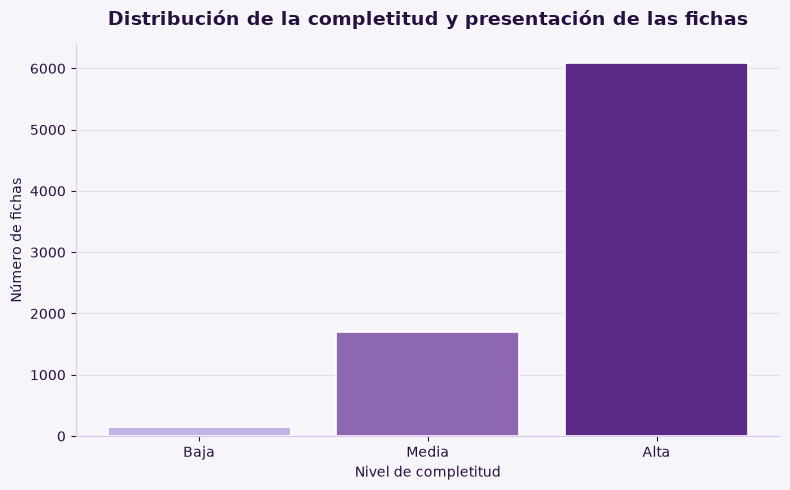

In [32]:
distribucion_completitud = (
    petfinder_app_integrado_df[
        "nivel_completitud_ficha"
    ]
    .value_counts()
    .reindex(
        [
            "Baja",
            "Media",
            "Alta"
        ],
        fill_value=0
    )
)


n_niveles_presentes = int(
    (
        distribucion_completitud > 0
    ).sum()
)


registrar_test(
    bloque="Completitud",
    prueba="El índice discrimina entre niveles",
    estado=(
        "PASS"
        if n_niveles_presentes >= 2
        else "FAIL"
    ),
    critico=True,
    detalle=(
        f"Niveles con observaciones: "
        f"{n_niveles_presentes}/3."
    ),
    metrica=n_niveles_presentes
)


registrar_test(
    bloque="Completitud",
    prueba="Existen fichas de completitud baja",
    estado=(
        "PASS"
        if distribucion_completitud[
            "Baja"
        ] > 0
        else "WARN"
    ),
    critico=False,
    detalle=(
        "La ausencia de fichas bajas sugeriría "
        "revisar si las reglas continúan siendo "
        "demasiado permisivas."
    ),
    metrica=int(
        distribucion_completitud[
            "Baja"
        ]
    )
)


display(
    distribucion_completitud
    .rename("n_fichas")
    .to_frame()
)


fig, ax = plt.subplots(
    figsize=(8, 5)
)

fig.patch.set_facecolor(
    COLOR_FONDO
)

ax.set_facecolor(
    COLOR_FONDO
)

ax.bar(
    distribucion_completitud.index,
    distribucion_completitud.values,
    color=[
        COLOR_CLARO,
        COLOR_MEDIO,
        COLOR_PRINCIPAL
    ],
    edgecolor="white",
    linewidth=1.2
)

ax.set_title(
    "Distribución de la completitud y presentación de las fichas",
    fontsize=14,
    fontweight="bold",
    color=COLOR_TEXTO,
    pad=14
)

ax.set_xlabel(
    "Nivel de completitud",
    color=COLOR_TEXTO
)

ax.set_ylabel(
    "Número de fichas",
    color=COLOR_TEXTO
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(COLOR_BORDE)
ax.spines["bottom"].set_color(COLOR_BORDE)

ax.tick_params(
    colors=COLOR_TEXTO
)

ax.grid(
    axis="y",
    linestyle="-",
    linewidth=0.7,
    alpha=0.18,
    color=COLOR_MEDIO
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


## 17. Validación del componente predictivo principal de Austin

Austin Animal Center constituye el **núcleo predictivo principal** para estimar riesgo de larga estancia. En este bloque se valida que el artefacto final puede cargarse y consumirse sin reentrenamiento, que conserva la configuración seleccionada, que produce probabilidades válidas y deterministas y que su latencia es compatible con un uso interactivo.

### 17.1. Contrato de entrada de la primera versión del MVP

El contrato de inferencia validado en este notebook **comienza en el dataset analítico preparado**, no en un registro crudo aislado de entrada al refugio. Esta decisión es deliberada: el modelo de Austin utiliza tanto información propia del perro como variables históricas y de contexto —por ejemplo, actividad reciente del refugio, entradas y salidas previas o estancias anteriores— que no pueden reconstruirse correctamente a partir de un único registro independiente.

Por tanto, este notebook **no presenta como end-to-end un flujo crudo → score que todavía no existe como componente reutilizable**. Una implantación futura que reciba datos crudos de otra protectora deberá convertir el feature engineering temporal desarrollado en la preparación de datos en un pipeline de inferencia reutilizable y validarlo de extremo a extremo antes de utilizar el modelo.

Dentro del contrato actual sí se prueban explícitamente la robustez ante **valores numéricos ausentes, categorías ausentes, categorías desconocidas, campos vacíos, varias ausencias simultáneas y columnas requeridas no proporcionadas**.

In [33]:
modelo_austin_guardado = None
dogs_austin_ready_df = None
probabilidades_austin_test = None
austin_validado = False
austin_runtime_metadata = {}


if not EJECUTAR_TEST_AUSTIN:

    registrar_test(
        bloque="Austin",
        prueba="Validación del componente principal",
        estado="SKIP",
        critico=True,
        detalle=(
            "EJECUTAR_TEST_AUSTIN = False. "
            "Debe activarse en la ejecución final."
        )
    )

elif not DEPENDENCIAS_AUSTIN_OK:

    registrar_test(
        bloque="Austin",
        prueba="Validación del componente principal",
        estado="FAIL",
        critico=True,
        detalle=(
            "El runtime de Austin no contiene todas "
            "las dependencias necesarias: "
            + str(faltantes_austin_final)
        )
    )

elif (
    modelo_austin_path is None
    or dataset_austin_preparado_path is None
):

    registrar_test(
        bloque="Austin",
        prueba="Validación del componente principal",
        estado="FAIL",
        critico=True,
        detalle=(
            "No se han localizado el modelo final "
            "y/o el dataset preparado de Austin."
        )
    )

else:

    try:
        import joblib
        import catboost
        import lightgbm

        # -------------------------------------------------------------
        # 1. Carga de artefactos
        # -------------------------------------------------------------

        modelo_austin_guardado = joblib.load(
            modelo_austin_path
        )

        dogs_austin_ready_df = pd.read_csv(
            dataset_austin_preparado_path
        )

        registrar_test(
            bloque="Austin",
            prueba="Carga del modelo final",
            estado="PASS",
            critico=True,
            detalle=str(modelo_austin_path)
        )

        registrar_test(
            bloque="Austin",
            prueba="Carga del dataset preparado",
            estado="PASS",
            critico=True,
            detalle=(
                f"{dogs_austin_ready_df.shape[0]} "
                f"registros × "
                f"{dogs_austin_ready_df.shape[1]} "
                "columnas."
            )
        )

        registrar_bool(
            bloque="Austin",
            prueba="Artefacto final es un diccionario",
            condicion=isinstance(
                modelo_austin_guardado,
                dict
            )
        )

        if not isinstance(
            modelo_austin_guardado,
            dict
        ):
            raise TypeError(
                "El artefacto Austin no tiene el "
                "formato de diccionario esperado."
            )

        # -------------------------------------------------------------
        # 2. Estructura y regresión de configuración
        # -------------------------------------------------------------

        claves_austin_necesarias = {
            "modelo_final_nombre",
            "usar_ensemble",
            "peso_catboost",
            "peso_lgbm",
            "umbral_decision",
            "modelo_catboost",
            "modelo_lgbm",
            "variables_catboost",
            "variables_lgbm"
        }

        claves_faltantes_austin = (
            claves_austin_necesarias
            - set(
                modelo_austin_guardado.keys()
            )
        )

        registrar_bool(
            bloque="Austin",
            prueba="Claves necesarias del artefacto",
            condicion=(
                len(claves_faltantes_austin) == 0
            ),
            detalle_pass=(
                "El artefacto contiene la "
                "configuración mínima de inferencia."
            ),
            detalle_fail=(
                "Faltan claves: "
                + str(
                    sorted(
                        claves_faltantes_austin
                    )
                )
            )
        )

        if len(claves_faltantes_austin) > 0:
            raise KeyError(
                "Faltan claves críticas del artefacto: "
                + str(
                    sorted(
                        claves_faltantes_austin
                    )
                )
            )

        nombre_modelo_austin = str(
            modelo_austin_guardado[
                "modelo_final_nombre"
            ]
        )

        usar_ensemble_austin = bool(
            modelo_austin_guardado[
                "usar_ensemble"
            ]
        )

        variables_catboost_austin = list(
            modelo_austin_guardado[
                "variables_catboost"
            ]
        )

        variables_lgbm_austin = list(
            modelo_austin_guardado[
                "variables_lgbm"
            ]
        )

        variables_categoricas_austin = list(
            modelo_austin_guardado.get(
                "variables_categoricas_catboost",
                []
            )
        )

        peso_catboost_austin = float(
            modelo_austin_guardado[
                "peso_catboost"
            ]
        )

        peso_lgbm_austin = float(
            modelo_austin_guardado[
                "peso_lgbm"
            ]
        )

        umbral_austin = float(
            modelo_austin_guardado[
                "umbral_decision"
            ]
        )

        registrar_bool(
            bloque="Austin",
            prueba="Regresión: modelo final esperado",
            condicion=(
                nombre_modelo_austin
                == "Ensemble CatBoost + LightGBM"
                and usar_ensemble_austin
            ),
            detalle_pass=nombre_modelo_austin,
            detalle_fail=(
                "Configuración observada: "
                f"{nombre_modelo_austin}; "
                f"usar_ensemble={usar_ensemble_austin}."
            )
        )

        registrar_bool(
            bloque="Austin",
            prueba="Regresión: número de variables",
            condicion=(
                len(variables_catboost_austin) == 41
                and len(variables_lgbm_austin) == 37
            ),
            detalle_pass=(
                "41 variables CatBoost y "
                "37 variables LightGBM."
            ),
            detalle_fail=(
                f"CatBoost={len(variables_catboost_austin)}, "
                f"LightGBM={len(variables_lgbm_austin)}."
            )
        )

        registrar_bool(
            bloque="Austin",
            prueba="Regresión: pesos y umbral finales",
            condicion=(
                np.isclose(
                    peso_catboost_austin,
                    0.725,
                    atol=1e-12
                )
                and np.isclose(
                    peso_lgbm_austin,
                    0.275,
                    atol=1e-12
                )
                and np.isclose(
                    umbral_austin,
                    0.24,
                    atol=1e-12
                )
            ),
            detalle_pass=(
                "Pesos 0.725 / 0.275 y umbral 0.24."
            ),
            detalle_fail=(
                f"Pesos observados: "
                f"{peso_catboost_austin:.6f} / "
                f"{peso_lgbm_austin:.6f}; "
                f"umbral={umbral_austin:.6f}."
            )
        )

        registrar_bool(
            bloque="Austin",
            prueba="Pesos del ensemble suman 1",
            condicion=np.isclose(
                peso_catboost_austin
                + peso_lgbm_austin,
                1.0,
                atol=1e-12
            )
        )

        registrar_bool(
            bloque="Austin",
            prueba="Umbral de decisión válido",
            condicion=(
                0 <= umbral_austin <= 1
            ),
            metrica=umbral_austin
        )

        # -------------------------------------------------------------
        # 3. Dataset preparado y variables
        # -------------------------------------------------------------

        registrar_bool(
            bloque="Austin",
            prueba="Regresión: dimensiones dataset preparado",
            condicion=(
                dogs_austin_ready_df.shape
                == (93803, 57)
            ),
            detalle_pass=(
                "Dataset final: 93.803 registros × "
                "57 columnas."
            ),
            detalle_fail=(
                "Dimensiones observadas: "
                + str(dogs_austin_ready_df.shape)
            )
        )

        columnas_minimas_austin = {
            "animal_id",
            "intake_datetime",
            "outcome_datetime",
            "stay_days",
            "stay_days_rounded",
            "target_long_stay"
        }

        registrar_bool(
            bloque="Austin",
            prueba="Columnas mínimas del dataset disponibles",
            condicion=(
                columnas_minimas_austin
                <= set(
                    dogs_austin_ready_df.columns
                )
            )
        )

        registrar_bool(
            bloque="Austin",
            prueba="Target Austin binario y completo",
            condicion=(
                dogs_austin_ready_df[
                    "target_long_stay"
                ]
                .notna()
                .all()
                and set(
                    dogs_austin_ready_df[
                        "target_long_stay"
                    ]
                    .unique()
                )
                <= {0, 1}
            )
        )

        variables_austin_faltantes = sorted(
            (
                set(variables_catboost_austin)
                | set(variables_lgbm_austin)
            )
            - set(
                dogs_austin_ready_df.columns
            )
        )

        registrar_bool(
            bloque="Austin",
            prueba="Variables de inferencia disponibles",
            condicion=(
                len(variables_austin_faltantes) == 0
            ),
            detalle_pass=(
                f"{len(variables_catboost_austin)} "
                "variables CatBoost y "
                f"{len(variables_lgbm_austin)} "
                "variables LightGBM disponibles."
            ),
            detalle_fail=(
                "Faltan: "
                + str(
                    variables_austin_faltantes
                )
            )
        )

        dataset_path_guardado = str(
            modelo_austin_guardado.get(
                "dataset_preparado_path",
                ""
            )
        )

        if dataset_path_guardado:
            registrar_bool(
                bloque="Austin",
                prueba="Artefacto referencia el dataset esperado",
                condicion=(
                    Path(
                        dataset_path_guardado
                    ).name
                    == dataset_austin_preparado_path.name
                ),
                detalle_pass=(
                    dataset_austin_preparado_path.name
                ),
                detalle_fail=(
                    "Ruta guardada en el artefacto: "
                    + dataset_path_guardado
                )
            )

        if len(variables_austin_faltantes) > 0:
            raise ValueError(
                "No puede ejecutarse inferencia porque "
                "faltan variables Austin."
            )

        # -------------------------------------------------------------
        # 4. Pipeline de inferencia
        # -------------------------------------------------------------

        def preparar_catboost_austin(X):
            X_preparado = X.copy()

            for variable in (
                variables_categoricas_austin
            ):
                if variable in X_preparado.columns:
                    X_preparado[
                        variable
                    ] = (
                        X_preparado[
                            variable
                        ]
                        .fillna(
                            "Sin información"
                        )
                        .astype(str)
                    )

            return X_preparado


        variables_requeridas_austin = sorted(
            set(variables_catboost_austin)
            | set(variables_lgbm_austin)
        )


        def inferir_austin(datos):
            if not isinstance(
                datos,
                pd.DataFrame
            ):
                raise TypeError(
                    "Austin espera un DataFrame."
                )

            columnas_ausentes = sorted(
                set(variables_requeridas_austin)
                - set(datos.columns)
            )

            if len(columnas_ausentes) > 0:
                raise ValueError(
                    "Faltan variables necesarias para "
                    "la inferencia de Austin: "
                    + ", ".join(columnas_ausentes)
                )

            if len(datos) == 0:
                return np.asarray(
                    [],
                    dtype=float
                )

            X_cat = preparar_catboost_austin(
                datos[
                    variables_catboost_austin
                ]
            )

            X_lgbm = (
                datos[
                    variables_lgbm_austin
                ]
                .copy()
            )

            proba_cat = (
                modelo_austin_guardado[
                    "modelo_catboost"
                ]
                .predict_proba(
                    X_cat
                )[:, 1]
            )

            proba_lgbm = (
                modelo_austin_guardado[
                    "modelo_lgbm"
                ]
                .predict_proba(
                    X_lgbm
                )[:, 1]
            )

            if usar_ensemble_austin:
                proba_final = (
                    peso_catboost_austin
                    * proba_cat
                    + peso_lgbm_austin
                    * proba_lgbm
                )
            else:
                nombre_lower = (
                    nombre_modelo_austin.lower()
                )

                if "catboost" in nombre_lower:
                    proba_final = proba_cat
                elif (
                    "lightgbm" in nombre_lower
                    or "lgbm" in nombre_lower
                ):
                    proba_final = proba_lgbm
                else:
                    raise ValueError(
                        "No se reconoce el modelo "
                        "final de Austin."
                    )

            return np.asarray(
                proba_final,
                dtype=float
            )

        # -------------------------------------------------------------
        # 5. Inferencia por lotes, determinismo y caso unitario
        # -------------------------------------------------------------

        muestra_austin = (
            dogs_austin_ready_df
            .sample(
                n=min(
                    N_MUESTRA_AUSTIN,
                    len(dogs_austin_ready_df)
                ),
                random_state=RANDOM_STATE
            )
            .copy()
        )

        probabilidades_austin_1 = inferir_austin(
            muestra_austin
        )

        probabilidades_austin_2 = inferir_austin(
            muestra_austin
        )

        probabilidades_austin_test = (
            probabilidades_austin_1
        )

        registrar_bool(
            bloque="Austin",
            prueba="Inferencia por lotes produce probabilidades válidas",
            condicion=(
                len(probabilidades_austin_1)
                == len(muestra_austin)
                and np.isfinite(
                    probabilidades_austin_1
                ).all()
                and np.all(
                    probabilidades_austin_1 >= 0
                )
                and np.all(
                    probabilidades_austin_1 <= 1
                )
            ),
            detalle_pass=(
                f"{len(probabilidades_austin_1)} "
                "predicciones válidas."
            )
        )

        registrar_bool(
            bloque="Austin",
            prueba="Inferencia determinista",
            condicion=np.allclose(
                probabilidades_austin_1,
                probabilidades_austin_2,
                rtol=0,
                atol=1e-12
            )
        )

        probabilidad_un_registro = inferir_austin(
            muestra_austin.iloc[[0]]
        )

        registrar_bool(
            bloque="Austin",
            prueba="Inferencia sobre un único registro",
            condicion=(
                probabilidad_un_registro.shape
                == (1,)
                and np.isfinite(
                    probabilidad_un_registro[0]
                )
                and 0 <= (
                    probabilidad_un_registro[0]
                ) <= 1
            ),
            detalle_pass=(
                "El modelo puede consumirse registro "
                "a registro desde una futura API."
            )
        )

        predicciones_binarias_austin = (
            probabilidades_austin_1
            >= umbral_austin
        ).astype(int)

        registrar_bool(
            bloque="Austin",
            prueba="Predicción binaria coherente con el umbral",
            condicion=(
                set(
                    np.unique(
                        predicciones_binarias_austin
                    )
                )
                <= {0, 1}
            )
        )

        # -------------------------------------------------------------
        # 6. Warm-up y benchmark de inferencia
        # -------------------------------------------------------------

        muestra_benchmark_austin = (
            muestra_austin
            .head(
                min(
                    32,
                    len(muestra_austin)
                )
            )
            .copy()
        )

        # Warm-up explícito.
        _ = inferir_austin(
            muestra_benchmark_austin
        )

        tiempos_austin = []

        for _ in range(
            N_BENCHMARK_AUSTIN
        ):
            inicio_austin = (
                time.perf_counter()
            )

            _ = inferir_austin(
                muestra_benchmark_austin
            )

            tiempos_austin.append(
                time.perf_counter()
                - inicio_austin
            )

        tiempos_austin = np.asarray(
            tiempos_austin,
            dtype=float
        )

        mediana_austin = float(
            np.median(
                tiempos_austin
            )
        )

        p95_austin = float(
            np.quantile(
                tiempos_austin,
                0.95
            )
        )

        registrar_test(
            bloque="Rendimiento",
            prueba="Latencia Austin tras warm-up (32 registros)",
            estado=(
                "PASS"
                if p95_austin <= 2.0
                else "WARN"
            ),
            critico=False,
            detalle=(
                "Benchmark de inferencia del ensemble "
                f"en {N_BENCHMARK_AUSTIN} repeticiones."
            ),
            metrica=p95_austin
        )

        # -------------------------------------------------------------
        # 7. Robustez ante datos faltantes y categorías nuevas
        # -------------------------------------------------------------

        fila_base_robustez = (
            muestra_austin
            .iloc[[0]]
            .copy()
        )


        def probabilidad_austin_valida(datos):
            try:
                probabilidad = inferir_austin(
                    datos
                )

            except Exception:
                return False

            return (
                probabilidad.shape == (len(datos),)
                and np.isfinite(
                    probabilidad
                ).all()
                and np.all(
                    probabilidad >= 0
                )
                and np.all(
                    probabilidad <= 1
                )
            )


        variables_numericas_austin = [
            variable
            for variable
            in variables_requeridas_austin
            if (
                variable
                in dogs_austin_ready_df.columns
                and pd.api.types.is_numeric_dtype(
                    dogs_austin_ready_df[
                        variable
                    ]
                )
            )
        ]


        variable_numerica_test = (
            "age_months_intake"
            if "age_months_intake"
            in variables_numericas_austin
            else variables_numericas_austin[0]
        )


        caso_numerico_nan = (
            fila_base_robustez
            .copy()
        )

        caso_numerico_nan.loc[
            :,
            variable_numerica_test
        ] = np.nan


        registrar_bool(
            bloque="Austin robustez",
            prueba="Valor numérico ausente",
            condicion=probabilidad_austin_valida(
                caso_numerico_nan
            ),
            critico=True,
            detalle_pass=(
                f"NaN controlado en "
                f"{variable_numerica_test}."
            )
        )


        variables_raza_test = [
            variable
            for variable
            in variables_requeridas_austin
            if (
                "breed" in variable.lower()
                and variable
                in dogs_austin_ready_df.columns
                and not pd.api.types.is_numeric_dtype(
                    dogs_austin_ready_df[
                        variable
                    ]
                )
            )
        ]


        if len(variables_raza_test) > 0:

            caso_raza_desconocida = (
                fila_base_robustez
                .copy()
            )

            for variable in (
                variables_raza_test
            ):
                caso_raza_desconocida.loc[
                    :,
                    variable
                ] = "__RAZA_DESCONOCIDA_TEST__"

            registrar_bool(
                bloque="Austin robustez",
                prueba="Raza o categoría de raza desconocida",
                condicion=probabilidad_austin_valida(
                    caso_raza_desconocida
                ),
                critico=True,
                detalle_pass=(
                    "Las variables categóricas de raza "
                    "aceptan un valor no observado sin "
                    "bloquear la inferencia: "
                    + ", ".join(
                        variables_raza_test
                    )
                    + "."
                )
            )

        else:

            registrar_test(
                bloque="Austin robustez",
                prueba="Raza o categoría de raza desconocida",
                estado="FAIL",
                critico=True,
                detalle=(
                    "No se ha localizado una variable "
                    "categórica de raza utilizable."
                )
            )


        variable_categorica_test = next(
            (
                variable
                for variable
                in [
                    "intake_condition",
                    "intake_type",
                    "sex",
                    "sterilized_intake"
                ]
                if variable
                in variables_requeridas_austin
            ),
            None
        )


        if variable_categorica_test is not None:

            caso_campo_vacio = (
                fila_base_robustez
                .copy()
            )

            caso_campo_vacio.loc[
                :,
                variable_categorica_test
            ] = ""

            registrar_bool(
                bloque="Austin robustez",
                prueba="Campo categórico vacío",
                condicion=probabilidad_austin_valida(
                    caso_campo_vacio
                ),
                critico=True,
                detalle_pass=(
                    f"Cadena vacía controlada en "
                    f"{variable_categorica_test}."
                )
            )

        else:

            registrar_test(
                bloque="Austin robustez",
                prueba="Campo categórico vacío",
                estado="FAIL",
                critico=True,
                detalle=(
                    "No se ha localizado una variable "
                    "categórica utilizable para este test."
                )
            )


        caso_varias_ausencias = (
            fila_base_robustez
            .copy()
        )

        caso_varias_ausencias.loc[
            :,
            variable_numerica_test
        ] = np.nan

        variables_para_ausencia_multiple = [
            variable
            for variable
            in [
                "breed_intake",
                "main_breed_grouped",
                "color_intake",
                "main_color_grouped",
                "found_location",
                "intake_condition"
            ]
            if variable
            in variables_requeridas_austin
        ][:3]

        for variable in (
            variables_para_ausencia_multiple
        ):
            caso_varias_ausencias.loc[
                :,
                variable
            ] = np.nan


        registrar_bool(
            bloque="Austin robustez",
            prueba="Varias ausencias simultáneas",
            condicion=probabilidad_austin_valida(
                caso_varias_ausencias
            ),
            critico=True,
            detalle_pass=(
                "El modelo mantiene una salida válida "
                "con varias variables ausentes."
            )
        )


        variable_columna_omitida = (
            variable_numerica_test
        )

        caso_columna_omitida = (
            fila_base_robustez
            .drop(
                columns=[
                    variable_columna_omitida
                ]
            )
        )

        try:
            inferir_austin(
                caso_columna_omitida
            )
            columna_omitida_controlada = False

        except ValueError as exc:
            columna_omitida_controlada = (
                "Faltan variables necesarias"
                in str(exc)
                and variable_columna_omitida
                in str(exc)
            )


        registrar_bool(
            bloque="Austin robustez",
            prueba="Columna requerida ausente",
            condicion=columna_omitida_controlada,
            critico=True,
            detalle_pass=(
                "La ausencia estructural de una "
                "variable genera un error explícito "
                "y controlado."
            )
        )


        # -------------------------------------------------------------
        # 8. Invisible Dog Score y bandas operativas
        # -------------------------------------------------------------

        def calcular_invisible_dog_score(
            probabilidades
        ):
            probabilidades = np.asarray(
                probabilidades,
                dtype=float
            )

            if (
                not np.isfinite(
                    probabilidades
                ).all()
                or np.any(
                    probabilidades < 0
                )
                or np.any(
                    probabilidades > 1
                )
            ):
                raise ValueError(
                    "Las probabilidades deben ser "
                    "finitas y pertenecer a [0, 1]."
                )

            return np.round(
                probabilidades * 100,
                1
            )


        def asignar_banda_riesgo_austin(
            score
        ):
            score = float(
                score
            )

            if not np.isfinite(score):
                raise ValueError(
                    "El score debe ser finito."
                )

            if score < 0 or score > 100:
                raise ValueError(
                    "El score debe pertenecer "
                    "a [0, 100]."
                )

            if score < 25:
                return "Bajo riesgo"

            if score < 50:
                return "Riesgo medio"

            if score < 75:
                return "Riesgo alto"

            return "Riesgo crítico"


        probabilidades_frontera_score = np.asarray(
            [
                0.000,
                0.249,
                0.250,
                0.499,
                0.500,
                0.749,
                0.750,
                1.000
            ],
            dtype=float
        )

        scores_frontera_esperados = np.asarray(
            [
                0.0,
                24.9,
                25.0,
                49.9,
                50.0,
                74.9,
                75.0,
                100.0
            ],
            dtype=float
        )

        bandas_frontera_esperadas = [
            "Bajo riesgo",
            "Bajo riesgo",
            "Riesgo medio",
            "Riesgo medio",
            "Riesgo alto",
            "Riesgo alto",
            "Riesgo crítico",
            "Riesgo crítico"
        ]


        scores_frontera_observados = (
            calcular_invisible_dog_score(
                probabilidades_frontera_score
            )
        )

        bandas_frontera_observadas = [
            asignar_banda_riesgo_austin(
                score
            )
            for score
            in scores_frontera_observados
        ]


        registrar_bool(
            bloque="Invisible Dog Score",
            prueba="Transformación probabilidad → score",
            condicion=np.allclose(
                scores_frontera_observados,
                scores_frontera_esperados,
                rtol=0,
                atol=1e-12
            ),
            critico=True,
            detalle_pass=(
                "Score = probabilidad × 100, "
                "redondeado a un decimal."
            )
        )


        registrar_bool(
            bloque="Invisible Dog Score",
            prueba="Bandas en los puntos de frontera",
            condicion=(
                bandas_frontera_observadas
                == bandas_frontera_esperadas
            ),
            critico=True,
            detalle_pass=(
                "Fronteras 25 / 50 / 75 "
                "reproducidas correctamente."
            )
        )


        scores_muestra_austin = (
            calcular_invisible_dog_score(
                probabilidades_austin_1
            )
        )

        registrar_bool(
            bloque="Invisible Dog Score",
            prueba="Score válido sobre inferencia Austin",
            condicion=(
                np.isfinite(
                    scores_muestra_austin
                ).all()
                and np.all(
                    scores_muestra_austin >= 0
                )
                and np.all(
                    scores_muestra_austin <= 100
                )
            ),
            critico=True
        )


        try:
            calcular_invisible_dog_score(
                [-0.1, 1.1]
            )
            probabilidad_invalida_controlada = False

        except ValueError:
            probabilidad_invalida_controlada = True


        registrar_bool(
            bloque="Invisible Dog Score",
            prueba="Probabilidad fuera de rango controlada",
            condicion=probabilidad_invalida_controlada,
            critico=True
        )


        # -------------------------------------------------------------
        # 9. Estado final y configuración runtime
        # -------------------------------------------------------------

        fallos_austin_criticos = [
            resultado
            for resultado
            in RESULTADOS_TEST
            if resultado.bloque in {
                "Austin",
                "Austin robustez",
                "Invisible Dog Score",
                "Entorno Austin"
            }
            and resultado.critico
            and resultado.estado == "FAIL"
        ]

        austin_validado = (
            len(fallos_austin_criticos) == 0
        )

        austin_runtime_metadata = {
            "validado": bool(
                austin_validado
            ),
            "modelo_final_nombre": (
                nombre_modelo_austin
            ),
            "usar_ensemble": bool(
                usar_ensemble_austin
            ),
            "peso_catboost": (
                peso_catboost_austin
            ),
            "peso_lgbm": (
                peso_lgbm_austin
            ),
            "umbral_decision": (
                umbral_austin
            ),
            "n_variables_catboost": int(
                len(
                    variables_catboost_austin
                )
            ),
            "n_variables_lgbm": int(
                len(
                    variables_lgbm_austin
                )
            ),
            "n_registros_dataset": int(
                len(
                    dogs_austin_ready_df
                )
            ),
            "versiones_runtime": (
                VERSIONES_RUNTIME_AUSTIN
            ),
            "modelo_path": str(
                modelo_austin_path
            ),
            "dataset_path": str(
                dataset_austin_preparado_path
            ),
            "latencia_p95_32_registros_s": (
                p95_austin
            ),
            "contrato_entrada": (
                "dataset_analitico_preparado"
            ),
            "acepta_registro_crudo_aislado": False,
            "invisible_dog_score": {
                "formula": (
                    "probabilidad_larga_estancia * 100"
                ),
                "redondeo_decimales": 1,
                "bandas": {
                    "bajo_riesgo": "[0, 25)",
                    "riesgo_medio": "[25, 50)",
                    "riesgo_alto": "[50, 75)",
                    "riesgo_critico": "[75, 100]"
                }
            }
        }

        austin_runtime_config_path = (
            app_ready_outputs_path
            / "invisible_dogs_austin_runtime_config.json"
        )

        with open(
            austin_runtime_config_path,
            "w",
            encoding="utf-8"
        ) as archivo:
            json.dump(
                austin_runtime_metadata,
                archivo,
                indent=4,
                ensure_ascii=False
            )

        registrar_bool(
            bloque="Austin",
            prueba="Componente principal preparado para el MVP",
            condicion=austin_validado,
            detalle_pass=(
                "Austin ha superado todos los "
                "tests críticos y su configuración "
                "runtime ha sido exportada."
            )
        )

        print(
            "Modelo Austin:",
            nombre_modelo_austin
        )
        print(
            "Pesos:",
            peso_catboost_austin,
            "/",
            peso_lgbm_austin
        )
        print(
            "Umbral:",
            umbral_austin
        )
        print(
            "Muestra inferida:",
            len(probabilidades_austin_1)
        )
        print(
            "Probabilidad mínima:",
            round(
                float(
                    probabilidades_austin_1.min()
                ),
                4
            )
        )
        print(
            "Probabilidad media:",
            round(
                float(
                    probabilidades_austin_1.mean()
                ),
                4
            )
        )
        print(
            "Probabilidad máxima:",
            round(
                float(
                    probabilidades_austin_1.max()
                ),
                4
            )
        )
        print(
            "Latencia mediana (32 registros):",
            f"{mediana_austin:.4f} s"
        )
        print(
            "Latencia P95 (32 registros):",
            f"{p95_austin:.4f} s"
        )
        print(
            "Austin validado para el MVP:",
            austin_validado
        )

    except Exception as exc:

        austin_validado = False

        registrar_test(
            bloque="Austin",
            prueba="Validación del componente principal",
            estado="FAIL",
            critico=True,
            detalle=(
                f"{type(exc).__name__}: "
                f"{exc}"
            )
        )

        print(
            "No se ha podido completar "
            "la validación de Austin:"
        )
        print(
            repr(exc)
        )

Modelo Austin: Ensemble CatBoost + LightGBM
Pesos: 0.725 / 0.275
Umbral: 0.24
Muestra inferida: 512
Probabilidad mínima: 0.0018
Probabilidad media: 0.163
Probabilidad máxima: 0.961
Latencia mediana (32 registros): 0.0274 s
Latencia P95 (32 registros): 0.0300 s
Austin validado para el MVP: True


### 17.2. Criterio de aceptación del componente Austin

La validación de Austin se considera satisfactoria únicamente si se superan tanto las comprobaciones del artefacto y de inferencia como los tests de robustez y la reconstrucción del **Invisible Dog Score**. La ausencia de una columna requerida se trata de forma diferente a un valor ausente: los `NaN` y categorías nuevas se gestionan dentro del contrato del modelo, mientras que una estructura de entrada incompleta debe producir un mensaje explícito en lugar de una predicción silenciosa.

La validación desde datos crudos queda documentada como **trabajo de industrialización futuro**, ya que requiere encapsular el feature engineering temporal e histórico de la preparación de Austin en un pipeline reutilizable. No se simula artificialmente ese flujo en este notebook.

## 18. Testing de la Vista Protectora

En este MVP, la vista se demuestra con **fichas individuales de PetFinder** porque el score complementario y las fotografías corresponden a los mismos registros.

En una aplicación real, esta misma interfaz consumiría el **riesgo principal de larga estancia generado por Austin** sobre un dataset analítico compatible de la protectora y podría expresarlo mediante el **Invisible Dog Score** y sus bandas operativas.

No se fusionan riesgo y completitud en un score único no validado. Se mantienen como **dos dimensiones independientes**.

In [34]:
def construir_vista_protectora(
    df
):
    resumen = {
        "n_fichas": int(
            len(df)
        ),
        "riesgo_alto": int(
            (
                df[
                    "nivel_riesgo_relativo"
                ]
                == "Alto"
            ).sum()
        ),
        "riesgo_medio": int(
            (
                df[
                    "nivel_riesgo_relativo"
                ]
                == "Medio"
            ).sum()
        ),
        "riesgo_bajo": int(
            (
                df[
                    "nivel_riesgo_relativo"
                ]
                == "Bajo"
            ).sum()
        ),
        "completitud_baja": int(
            (
                df[
                    "nivel_completitud_ficha"
                ]
                == "Baja"
            ).sum()
        )
    }

    prioridad_atencion = (
        df
        .loc[
            df[
                "nivel_riesgo_relativo"
            ].eq("Alto")
        ]
        .copy()
        .sort_values(
            [
                "indice_completitud_ficha",
                score_col
            ],
            ascending=[
                True,
                False
            ]
        )
    )

    return resumen, prioridad_atencion


resumen_protectora, prioridad_protectora_df = (
    construir_vista_protectora(
        petfinder_adoptante_base_df
    )
)


registrar_bool(
    bloque="Vista protectora",
    prueba="KPIs suman la población",
    condicion=(
        resumen_protectora[
            "riesgo_alto"
        ]
        + resumen_protectora[
            "riesgo_medio"
        ]
        + resumen_protectora[
            "riesgo_bajo"
        ]
        == resumen_protectora[
            "n_fichas"
        ]
    )
)


registrar_bool(
    bloque="Vista protectora",
    prueba="Listado de atención contiene riesgo alto",
    condicion=(
        len(prioridad_protectora_df) == 0
        or prioridad_protectora_df[
            "nivel_riesgo_relativo"
        ]
        .eq("Alto")
        .all()
    )
)


display(
    pd.DataFrame(
        [resumen_protectora]
    )
)

display(
    prioridad_protectora_df[
        [
            "PetID",
            "nombre_app",
            score_col,
            "nivel_riesgo_relativo",
            "indice_completitud_ficha",
            "nivel_completitud_ficha",
            "PhotoAmt",
            "VideoAmt"
        ]
    ]
    .head(15)
    .round({
        score_col: 4,
        "indice_completitud_ficha": 3
    })
)

,n_fichas,riesgo_alto,riesgo_medio,riesgo_bajo,completitud_baja
0,6474,2124,2041,2309,127


,PetID,nombre_app,prob_adopcion_lenta_petfinder_final,nivel_riesgo_relativo,indice_completitud_ficha,nivel_completitud_ficha,PhotoAmt,VideoAmt
1753,bfdc4cd9d,Baby,0.7769,Alto,0.25,Baja,1.0,0
1820,21e4ca7d1,Ori,0.7641,Alto,0.25,Baja,2.0,0
5438,fc7f99ad7,Sin nombre,0.8441,Alto,0.30,Baja,1.0,0
6174,5e3dc5d76,Sin nombre,0.8193,Alto,0.30,Baja,1.0,0
1224,662011890,Sin nombre,0.7836,Alto,0.30,Baja,1.0,0
6471,f5dc70d35,Sin nombre,0.7775,Alto,0.30,Baja,1.0,0
2099,660cd67ed,Sin nombre,0.7718,Alto,0.30,Baja,1.0,0
2685,c40b30ff3,Sin nombre,0.7293,Alto,0.30,Baja,1.0,0
220,3c5e8cc5d,Sin nombre,0.7265,Alto,0.30,Baja,1.0,0
2266,0b3b23c20,Sin nombre,0.7180,Alto,0.30,Baja,1.0,0


### 18.1. Matriz riesgo × completitud

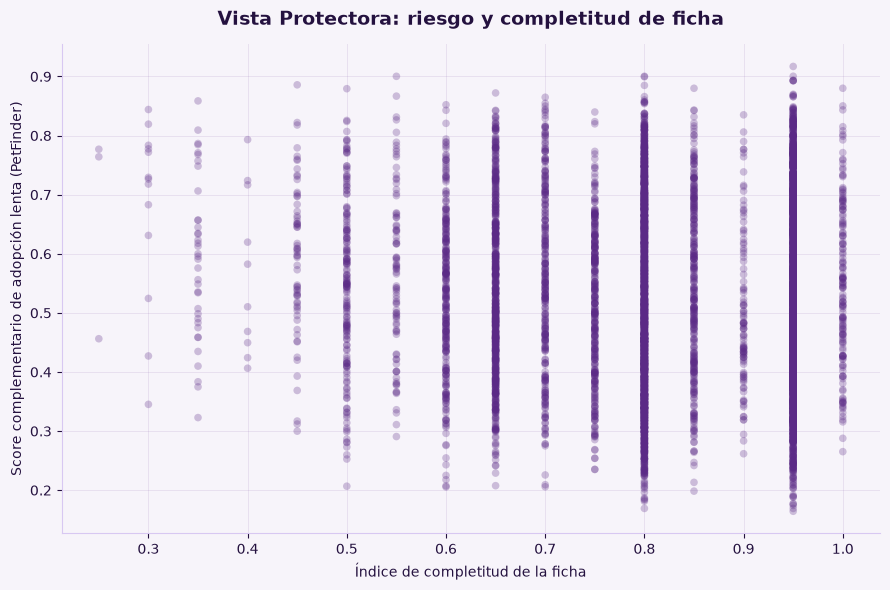

In [35]:
orden_riesgo = {
    "Bajo": 1,
    "Medio": 2,
    "Alto": 3
}

df_matriz = (
    petfinder_adoptante_base_df
    .assign(
        riesgo_ordinal=lambda df:
        df[
            "nivel_riesgo_relativo"
        ]
        .map(orden_riesgo)
    )
)


fig, ax = plt.subplots(
    figsize=(9, 6)
)

fig.patch.set_facecolor(
    COLOR_FONDO
)

ax.set_facecolor(
    COLOR_FONDO
)

ax.scatter(
    df_matriz[
        "indice_completitud_ficha"
    ],
    df_matriz[
        score_col
    ],
    alpha=0.28,
    s=30,
    color=COLOR_PRINCIPAL,
    edgecolors="none"
)

ax.set_title(
    "Vista Protectora: riesgo y completitud de ficha",
    fontsize=14,
    fontweight="bold",
    color=COLOR_TEXTO,
    pad=14
)

ax.set_xlabel(
    "Índice de completitud de la ficha",
    color=COLOR_TEXTO
)

ax.set_ylabel(
    "Score complementario de adopción lenta (PetFinder)",
    color=COLOR_TEXTO
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(COLOR_BORDE)
ax.spines["bottom"].set_color(COLOR_BORDE)

ax.tick_params(
    colors=COLOR_TEXTO
)

ax.grid(
    linestyle="-",
    linewidth=0.7,
    alpha=0.14,
    color=COLOR_MEDIO
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


## 19. Rendimiento del sistema

La aplicación no recalculará embeddings de todos los perros durante cada búsqueda. Los embeddings y prototipos ya están precalculados.

Se mide la latencia de:

- filtros estructurados;
- ranking DINOv2 por raza;
- filtros + ranking;
- modo descubrimiento;
- priorización de riesgo.

La inferencia de una fotografía se ha medido previamente **después de warm-up**, y el componente de Austin registra también su propia latencia.

In [36]:
def medir_latencia(
    funcion,
    n_repeticiones=50
):
    tiempos = []

    for _ in range(
        n_repeticiones
    ):
        inicio = time.perf_counter()

        funcion()

        tiempos.append(
            time.perf_counter()
            - inicio
        )

    tiempos = np.asarray(
        tiempos,
        dtype=float
    )

    return {
        "media_ms": float(
            tiempos.mean() * 1000
        ),
        "p95_ms": float(
            np.quantile(
                tiempos,
                0.95
            ) * 1000
        ),
        "max_ms": float(
            tiempos.max() * 1000
        )
    }


rendimiento_filtros = medir_latencia(
    lambda:
    aplicar_filtros_adoptante(
        petfinder_adoptante_base_df,
        **PREFERENCIAS_DEMO
    )
)

rendimiento_busqueda = medir_latencia(
    lambda:
    buscar_por_apariencia(
        RAZA_TEST_VISUAL,
        top_k=12
    )
)

rendimiento_integrado = medir_latencia(
    lambda:
    buscar_por_apariencia(
        RAZA_TEST_VISUAL,
        df_candidatos=(
            aplicar_filtros_adoptante(
                petfinder_adoptante_base_df,
                **PREFERENCIAS_DEMO
            )
        ),
        top_k=12
    )
)

rendimiento_descubrimiento = medir_latencia(
    lambda:
    seleccionar_modo_descubrimiento(
        ranking_pool_descubrimiento,
        n_resultados=12,
        pool_size=80,
        n_anclas=6,
        n_alternativos=4,
        lambda_similitud=0.60,
        similitud_minima_relativa=0.90
    ),
    n_repeticiones=20
)

rendimiento_priorizacion = medir_latencia(
    lambda:
    priorizar_riesgo_entre_compatibles(
        ranking_pool_riesgo,
        n_resultados=12,
        pool_compatible=30,
        activar_priorizacion=True
    ),
    n_repeticiones=50
)


rendimiento_df = pd.DataFrame([
    {
        "operacion": "Filtros estructurados",
        **rendimiento_filtros
    },
    {
        "operacion": "Ranking visual DINOv2",
        **rendimiento_busqueda
    },
    {
        "operacion": "Filtros + ranking",
        **rendimiento_integrado
    },
    {
        "operacion": "Modo descubrimiento",
        **rendimiento_descubrimiento
    },
    {
        "operacion": "Priorización de riesgo",
        **rendimiento_priorizacion
    }
])


display(
    rendimiento_df.round(3)
)


for fila in rendimiento_df.itertuples(
    index=False
):
    registrar_test(
        bloque="Rendimiento",
        prueba=f"Latencia: {fila.operacion}",
        estado=(
            "PASS"
            if fila.p95_ms <= 250
            else "WARN"
        ),
        critico=False,
        detalle=(
            "Umbral orientativo: "
            "p95 ≤ 250 ms."
        ),
        metrica=float(
            fila.p95_ms
        )
    )

,operacion,media_ms,p95_ms,max_ms
0,Filtros estructurados,4.143,7.800,9.352
1,Ranking visual DINOv2,14.755,23.267,30.625
2,Filtros + ranking,10.614,13.715,46.503
3,Modo descubrimiento,15.098,17.911,18.343
4,Priorización de riesgo,11.016,9.470,282.707


## 20. Casos extremos y robustez

Este bloque recoge los casos extremos generales del buscador y de la lógica de interacción. Los casos específicos del núcleo Austin —valores ausentes, categorías desconocidas, campos vacíos y columnas requeridas ausentes— se validan dentro de su propio bloque para mantener separado el contrato del modelo predictivo del contrato de la capa visual.

In [37]:
# DataFrame vacío.

df_vacio = (
    petfinder_adoptante_base_df
    .head(0)
    .copy()
)

ranking_vacio = buscar_por_apariencia(
    RAZA_TEST_VISUAL,
    df_candidatos=df_vacio,
    top_k=12
)

registrar_bool(
    bloque="Casos extremos",
    prueba="Ranking con candidatos vacíos",
    condicion=(
        len(ranking_vacio) == 0
    )
)


# Vector nulo.

try:
    buscar_por_vector(
        np.zeros(
            dimension_config,
            dtype=np.float32
        )
    )

    vector_nulo_controlado = False

except ValueError:
    vector_nulo_controlado = True


registrar_bool(
    bloque="Casos extremos",
    prueba="Vector de referencia nulo controlado",
    condicion=vector_nulo_controlado
)


# Dimensión incorrecta.

try:
    buscar_por_vector(
        np.ones(
            dimension_config + 1,
            dtype=np.float32
        )
    )

    dimension_incorrecta_controlada = False

except ValueError:
    dimension_incorrecta_controlada = True


registrar_bool(
    bloque="Casos extremos",
    prueba="Dimensión incorrecta controlada",
    condicion=dimension_incorrecta_controlada
)


# Parámetros inválidos del modo descubrimiento.

try:
    seleccionar_modo_descubrimiento(
        ranking_pool_descubrimiento,
        lambda_similitud=1.5
    )

    lambda_invalida_controlada = False

except ValueError:
    lambda_invalida_controlada = True


registrar_bool(
    bloque="Casos extremos",
    prueba="Parámetro MMR inválido controlado",
    condicion=lambda_invalida_controlada
)


try:
    seleccionar_modo_descubrimiento(
        ranking_pool_descubrimiento,
        similitud_minima_relativa=0
    )

    similitud_relativa_invalida_controlada = False

except ValueError:
    similitud_relativa_invalida_controlada = True


registrar_bool(
    bloque="Casos extremos",
    prueba="Umbral relativo inválido controlado",
    condicion=similitud_relativa_invalida_controlada
)


# Comparación con lista vacía de favoritos.

comparacion_vacia_df = (
    preparar_comparacion(
        petfinder_adoptante_base_df,
        [],
        max_perros=4
    )
)

registrar_bool(
    bloque="Casos extremos",
    prueba="Comparación sin favoritos controlada",
    condicion=(
        len(comparacion_vacia_df) == 0
    )
)

## 21. Preparación de artefactos finales para el MVP

Se preparan dos datasets de consumo para la futura aplicación:

1. un índice integrado que conserva todas las fichas de PetFinder;
2. una versión específica para el recorrido del adoptante, limitada a fichas individuales.

Además, se exporta la configuración funcional y el contrato de ejecución de Austin. De este modo, el Notebook 09 / aplicación Streamlit no tendrá que reconstruir la lógica de integración desarrollada y validada en este notebook.

In [38]:
columnas_componentes_completitud = list(
    PESOS_COMPLETITUD.keys()
)


columnas_app_ready = [
    "indice_embedding",
    "PetID",
    "nombre_app",
    "ruta_imagen_principal",
    "Quantity",
    "tipo_ficha_app",
    "Age",
    "edad_anos",
    "sexo_app",
    "tamano_app",
    "pelo_app",
    "salud_app",
    "esterilizado_app",
    "vacunado_app",
    "desparasitado_app",
    "raza_principal_app",
    "raza_secundaria_app",
    "color_1_app",
    "color_2_app",
    "color_3_app",
    "PhotoAmt",
    "VideoAmt",
    "Description",
    *[
        columna
        for columna in [
            "image_width",
            "image_height",
            "image_aspect_ratio"
        ]
        if columna
        in petfinder_app_integrado_df.columns
    ],
    score_col,
    "nivel_riesgo_relativo",
    "origen_score_petfinder_final",
    *columnas_componentes_completitud,
    "indice_completitud_ficha",
    "nivel_completitud_ficha"
]


columnas_app_ready_faltantes = [
    columna
    for columna
    in columnas_app_ready
    if columna
    not in petfinder_app_integrado_df.columns
]


registrar_bool(
    bloque="Exportación",
    prueba="Columnas finales disponibles",
    condicion=(
        len(
            columnas_app_ready_faltantes
        ) == 0
    ),
    detalle_fail=(
        "Faltan: "
        + str(
            columnas_app_ready_faltantes
        )
    )
)


if len(
    columnas_app_ready_faltantes
) == 0:

    petfinder_app_ready_df = (
        petfinder_app_integrado_df[
            columnas_app_ready
        ]
        .copy()
    )

    petfinder_adoptante_ready_df = (
        petfinder_app_ready_df
        .loc[
            petfinder_app_ready_df[
                "tipo_ficha_app"
            ]
            .eq("Individual")
        ]
        .copy()
    )


    petfinder_app_ready_path = (
        app_ready_outputs_path
        / "invisible_dogs_petfinder_app_ready.csv"
    )

    petfinder_adoptante_ready_path = (
        app_ready_outputs_path
        / "invisible_dogs_petfinder_adoptante_ready.csv"
    )


    petfinder_app_ready_df.to_csv(
        petfinder_app_ready_path,
        index=False,
        encoding="utf-8-sig"
    )

    petfinder_adoptante_ready_df.to_csv(
        petfinder_adoptante_ready_path,
        index=False,
        encoding="utf-8-sig"
    )


    registrar_bool(
        bloque="Exportación",
        prueba="Dataset adoptante contiene solo individuales",
        condicion=(
            petfinder_adoptante_ready_df[
                "tipo_ficha_app"
            ]
            .eq("Individual")
            .all()
        ),
        detalle_pass=(
            f"{len(petfinder_adoptante_ready_df)} "
            "fichas preparadas."
        )
    )


    print(
        "Dataset integrado guardado en:"
    )

    print(
        petfinder_app_ready_path
    )

    print(
        "\nDataset del adoptante guardado en:"
    )

    print(
        petfinder_adoptante_ready_path
    )

Dataset integrado guardado en:
G:\Mi unidad\TFM\invisible-dogs-tfm\outputs\app_ready\invisible_dogs_petfinder_app_ready.csv

Dataset del adoptante guardado en:
G:\Mi unidad\TFM\invisible-dogs-tfm\outputs\app_ready\invisible_dogs_petfinder_adoptante_ready.csv


### 21.1. Configuración funcional del MVP

In [39]:
configuracion_mvp = {
    "version": "08_testing_integracion_final",
    "modelo_visual": (
        configuracion_busqueda_app[
            "modelo_visual"
        ]
    ),
    "dimension_embedding": (
        dimension_config
    ),
    "metrica_similitud": (
        configuracion_busqueda_app.get(
            "metrica_similitud",
            "cosine_similarity"
        )
    ),
    "filtros_disponibles": [
        "edad",
        "sexo",
        "tamano",
        "pelo",
        "salud",
        "esterilizacion",
        "vacunacion",
        "desparasitacion",
        "raza_registrada",
        "color"
    ],
    "solo_fichas_individuales_adoptante_por_defecto": True,
    "busqueda_por_raza": True,
    "busqueda_por_fotografia": True,
    "filtros_inteligentes": True,
    "modo_descubrimiento": {
        "activo": True,
        "n_resultados": 12,
        "pool_size": 80,
        "n_anclas": 6,
        "n_alternativos": 4,
        "lambda_similitud": 0.60,
        "similitud_minima_relativa": 0.90
    },
    "priorizacion_riesgo": {
        "activa": True,
        "pool_compatible": 30,
        "metodo": (
            "ordenar por riesgo dentro del "
            "pool visual compatible, con similitud "
            "como criterio secundario"
        ),
        "score_combinado": False
    },
    "favoritos_y_comparacion": True,
    "max_perros_comparacion": 4,
    "completitud_ficha": {
        "activa": True,
        "tipo": "reglas_transparentes",
        "pesos": PESOS_COMPLETITUD,
        "umbrales": {
            "baja": "< 0.50",
            "media": "0.50 - < 0.75",
            "alta": ">= 0.75"
        }
    },
    "vista_protectora": True,
    "invisible_dog_score_austin": {
        "activo": True,
        "formula": "probabilidad_larga_estancia * 100",
        "redondeo_decimales": 1,
        "bandas": {
            "bajo_riesgo": "[0, 25)",
            "riesgo_medio": "[25, 50)",
            "riesgo_alto": "[50, 75)",
            "riesgo_critico": "[75, 100]"
        }
    },
    "modelo_principal_austin": {
        "nombre_artefacto": "modelo_final_invisible_dogs.pkl",
        "validado_en_notebook_08": bool(
            austin_validado
        ),
        "runtime": (
            austin_runtime_metadata
            if austin_validado
            else {}
        ),
        "contrato_entrada": (
            "dataset_analitico_preparado"
        ),
        "acepta_registro_crudo_aislado": False
    },
    "componentes_fuera_runtime_mvp": [
        "SHAP del Notebook 03",
        "regresion de dias del Notebook 04",
        "EfficientNet-B0 y Grad-CAM del Notebook 06",
        "CLIP como buscador final"
    ],
    "nota_metodologica": (
        "Austin es el núcleo predictivo principal. "
        "PetFinder se utiliza en el MVP para demostrar "
        "la integración sobre fichas con fotografía y "
        "score complementario. Tsinghua Dogs y DINOv2 "
        "aportan la capa de búsqueda visual."
    )
}


configuracion_mvp_path = (
    app_ready_outputs_path
    / "invisible_dogs_mvp_config.json"
)


with open(
    configuracion_mvp_path,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        configuracion_mvp,
        archivo,
        indent=4,
        ensure_ascii=False
    )


print(
    "Configuración del MVP guardada en:"
)

print(
    configuracion_mvp_path
)

Configuración del MVP guardada en:
G:\Mi unidad\TFM\invisible-dogs-tfm\outputs\app_ready\invisible_dogs_mvp_config.json


## 22. Resultado global del testing

In [40]:
resultados_df = resultados_test_df()

orden_estado = {
    "FAIL": 0,
    "SKIP": 1,
    "WARN": 2,
    "PASS": 3
}

resultados_df[
    "_orden_estado"
] = (
    resultados_df[
        "estado"
    ]
    .map(
        orden_estado
    )
)

resultados_df = (
    resultados_df
    .sort_values(
        [
            "critico",
            "_orden_estado",
            "bloque",
            "prueba"
        ],
        ascending=[
            False,
            True,
            True,
            True
        ]
    )
    .drop(
        columns=[
            "_orden_estado"
        ]
    )
    .reset_index(drop=True)
)


display(
    resultados_df
)


resumen_estados = (
    resultados_df[
        "estado"
    ]
    .value_counts()
    .reindex(
        [
            "PASS",
            "WARN",
            "SKIP",
            "FAIL"
        ],
        fill_value=0
    )
)


print(
    "Resumen de estados:"
)

display(
    resumen_estados
    .rename("n_pruebas")
    .to_frame()
)


bloqueos_criticos_df = (
    resultados_df
    .loc[
        resultados_df[
            "critico"
        ]
        & resultados_df[
            "estado"
        ]
        .isin(
            [
                "FAIL",
                "SKIP"
            ]
        )
    ]
    .copy()
)


resultado_global = (
    "GO"
    if len(
        bloqueos_criticos_df
    ) == 0
    else "NO GO"
)


print()
print(
    "RESULTADO GLOBAL:"
)

print(
    resultado_global
)


if len(
    bloqueos_criticos_df
) > 0:

    print(
        "\nBloqueos críticos:"
    )

    display(
        bloqueos_criticos_df[
            [
                "bloque",
                "prueba",
                "estado",
                "detalle"
            ]
        ]
    )


,bloque,prueba,estado,critico,detalle,metrica
0,Artefactos,Existe: Breed labels,PASS,True,G:\Mi unidad\TFM\invisible-dogs-tfm\data\raw_p...,NaN
1,Artefactos,Existe: Catálogo de razas,PASS,True,G:\Mi unidad\TFM\invisible-dogs-tfm\outputs\ts...,NaN
2,Artefactos,Existe: Color labels,PASS,True,G:\Mi unidad\TFM\invisible-dogs-tfm\data\raw_p...,NaN
3,Artefactos,Existe: Configuración del buscador,PASS,True,G:\Mi unidad\TFM\invisible-dogs-tfm\outputs\ts...,NaN
4,Artefactos,Existe: Dataset PetFinder puntuado,PASS,True,G:\Mi unidad\TFM\invisible-dogs-tfm\data\proce...,NaN
...,...,...,...,...,...,...
127,Rendimiento,Latencia: Filtros + ranking,PASS,False,Umbral orientativo: p95 ≤ 250 ms.,13.715085
128,Rendimiento,Latencia: Filtros estructurados,PASS,False,Umbral orientativo: p95 ≤ 250 ms.,7.799620
129,Rendimiento,Latencia: Modo descubrimiento,PASS,False,Umbral orientativo: p95 ≤ 250 ms.,17.911400
130,Rendimiento,Latencia: Priorización de riesgo,PASS,False,Umbral orientativo: p95 ≤ 250 ms.,9.470125


Resumen de estados:


,n_pruebas
estado,
PASS,132
WARN,0
SKIP,0
FAIL,0



RESULTADO GLOBAL:
GO


### 22.1. Visualización del estado del sistema

La representación resume exclusivamente las **pruebas registradas**. El resultado `GO / NO GO` se calcula a partir de ellas como criterio de cierre y, por tanto, **no se contabiliza como una prueba adicional**.


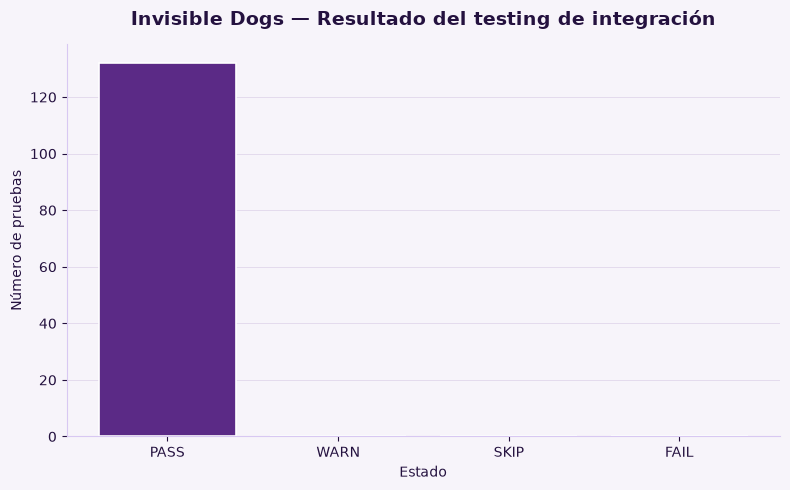

In [41]:
# Se utiliza el registro definitivo de pruebas.
# El estado GO/NO GO es una conclusión derivada y no añade una prueba adicional.

resultados_df = resultados_test_df()

resumen_estados_final = (
    resultados_df[
        "estado"
    ]
    .value_counts()
    .reindex(
        [
            "PASS",
            "WARN",
            "SKIP",
            "FAIL"
        ],
        fill_value=0
    )
)


fig, ax = plt.subplots(
    figsize=(8, 5)
)

fig.patch.set_facecolor(
    COLOR_FONDO
)

ax.set_facecolor(
    COLOR_FONDO
)

ax.bar(
    resumen_estados_final.index,
    resumen_estados_final.values,
    color=[
        COLOR_PRINCIPAL,
        COLOR_MEDIO,
        COLOR_CLARO,
        COLOR_BORDE
    ],
    edgecolor="white",
    linewidth=1.2
)

ax.set_title(
    "Invisible Dogs — Resultado del testing de integración",
    fontsize=14,
    fontweight="bold",
    color=COLOR_TEXTO,
    pad=14
)

ax.set_xlabel(
    "Estado",
    color=COLOR_TEXTO
)

ax.set_ylabel(
    "Número de pruebas",
    color=COLOR_TEXTO
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(COLOR_BORDE)
ax.spines["bottom"].set_color(COLOR_BORDE)

ax.tick_params(
    colors=COLOR_TEXTO
)

ax.grid(
    axis="y",
    linestyle="-",
    linewidth=0.7,
    alpha=0.18,
    color=COLOR_MEDIO
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


### 22.2. Resumen narrativo automático

La siguiente celda convierte el registro de pruebas en un resumen legible para la memoria y la defensa. El texto se genera a partir de la ejecución real, por lo que no depende de cifras escritas manualmente.

In [42]:
from IPython.display import Markdown, display as display_markdown


resultados_resumen_df = resultados_test_df()

n_total_final = int(
    len(
        resultados_resumen_df
    )
)

n_pass_final = int(
    resultados_resumen_df[
        "estado"
    ]
    .eq("PASS")
    .sum()
)

n_warn_final = int(
    resultados_resumen_df[
        "estado"
    ]
    .eq("WARN")
    .sum()
)

n_skip_final = int(
    resultados_resumen_df[
        "estado"
    ]
    .eq("SKIP")
    .sum()
)

n_fail_final = int(
    resultados_resumen_df[
        "estado"
    ]
    .eq("FAIL")
    .sum()
)

n_bloqueos_final = int(
    (
        resultados_resumen_df[
            "critico"
        ]
        & resultados_resumen_df[
            "estado"
        ]
        .isin(
            [
                "FAIL",
                "SKIP"
            ]
        )
    )
    .sum()
)

resultado_narrativo = (
    "GO"
    if n_bloqueos_final == 0
    else "NO GO"
)


if resultado_narrativo == "GO":

    texto_resumen = f"""
> **Resultado de validación:** **{n_pass_final}/{n_total_final} pruebas PASS** — \
{n_warn_final} WARN, {n_skip_final} SKIP y {n_fail_final} FAIL. \
**Resultado global: GO para el desarrollo del MVP.**

La ejecución confirma que los componentes incluidos en el alcance funcional del MVP \
han superado sus criterios críticos de integridad, inferencia, robustez e integración.
"""

else:

    texto_resumen = f"""
> **Resultado de validación:** {n_pass_final}/{n_total_final} pruebas PASS — \
{n_warn_final} WARN, {n_skip_final} SKIP y {n_fail_final} FAIL. \
**Resultado global: NO GO.**

Persisten **{n_bloqueos_final} bloqueos críticos** que deben resolverse antes de \
considerar cerrada la fase de testing.
"""


display_markdown(
    Markdown(
        texto_resumen
    )
)


> **Resultado de validación:** **132/132 pruebas PASS** — 0 WARN, 0 SKIP y 0 FAIL. **Resultado global: GO para el desarrollo del MVP.**

La ejecución confirma que los componentes incluidos en el alcance funcional del MVP han superado sus criterios críticos de integridad, inferencia, robustez e integración.


## 23. Exportación del informe de testing

In [43]:
resultados_df = resultados_test_df()

testing_report_path = (
    testing_outputs_path
    / "invisible_dogs_testing_report_final.csv"
)

resultados_df.to_csv(
    testing_report_path,
    index=False,
    encoding="utf-8-sig"
)


testing_summary_path = (
    testing_outputs_path
    / "invisible_dogs_testing_summary_final.json"
)


n_bloqueos_criticos = int(
    (
        resultados_df[
            "critico"
        ]
        & resultados_df[
            "estado"
        ]
        .isin(
            [
                "FAIL",
                "SKIP"
            ]
        )
    ).sum()
)


resumen_testing = {
    "total_pruebas": int(
        len(
            resultados_df
        )
    ),
    "pass": int(
        (
            resultados_df[
                "estado"
            ] == "PASS"
        ).sum()
    ),
    "warn": int(
        (
            resultados_df[
                "estado"
            ] == "WARN"
        ).sum()
    ),
    "skip": int(
        (
            resultados_df[
                "estado"
            ] == "SKIP"
        ).sum()
    ),
    "fail": int(
        (
            resultados_df[
                "estado"
            ] == "FAIL"
        ).sum()
    ),
    "bloqueos_criticos": (
        n_bloqueos_criticos
    ),
    "resultado_global": (
        "GO"
        if n_bloqueos_criticos == 0
        else "NO GO"
    )
}


with open(
    testing_summary_path,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        resumen_testing,
        archivo,
        indent=4,
        ensure_ascii=False
    )


print(
    "Informe CSV:"
)

print(
    testing_report_path
)

print(
    "\nResumen JSON:"
)

print(
    testing_summary_path
)

print(
    "\nResumen final:"
)

print(
    json.dumps(
        resumen_testing,
        indent=4,
        ensure_ascii=False
    )
)

Informe CSV:
G:\Mi unidad\TFM\invisible-dogs-tfm\outputs\testing\invisible_dogs_testing_report_final.csv

Resumen JSON:
G:\Mi unidad\TFM\invisible-dogs-tfm\outputs\testing\invisible_dogs_testing_summary_final.json

Resumen final:
{
    "total_pruebas": 132,
    "pass": 132,
    "warn": 0,
    "skip": 0,
    "fail": 0,
    "bloqueos_criticos": 0,
    "resultado_global": "GO"
}


## 24. Conclusión final

El Notebook 08 cierra la fase de **validación, testing e integración** previa al desarrollo del MVP. La decisión de avanzar no se basa en una revisión manual aislada, sino en un registro reproducible de pruebas con estados `PASS`, `WARN`, `SKIP` y `FAIL`, donde cualquier `FAIL` o `SKIP` crítico impide obtener un resultado global `GO`.

La validación cubre la alineación entre PetID, metadatos, fotografías, embeddings DINOv2 y scores de PetFinder; los filtros estructurados y combinados; la búsqueda visual por raza y fotografía; los filtros inteligentes; el modo descubrimiento; la priorización de visibilidad por riesgo sin crear un score combinado arbitrario; favoritos, comparación y explicabilidad; la completitud de las fichas; la Vista Protectora; el rendimiento; y los principales casos extremos.

El componente de **Austin Animal Center** se valida de forma independiente como núcleo predictivo de larga estancia. El contrato actual parte del dataset analítico preparado y comprueba la carga del ensemble CatBoost + LightGBM, la coherencia de su configuración, la inferencia unitaria y por lotes, el determinismo, el rendimiento y la robustez ante datos incompletos o categorías no observadas. También se reproduce la transformación de la probabilidad al **Invisible Dog Score** y sus bandas operativas.

No se presenta como validado un pipeline crudo → score para Austin, porque las variables históricas y temporales del modelo requieren un proceso de feature engineering que todavía no se ha encapsulado como componente de inferencia reutilizable. Del mismo modo, SHAP, la regresión complementaria de días, EfficientNet-B0, Grad-CAM y CLIP quedan documentados como análisis o extensiones fuera del runtime inicial del MVP.

Cuando el resumen automático anterior devuelve **GO**, los componentes funcionales necesarios quedan preparados para trasladarse al Notebook 09 y a la aplicación Streamlit sin reabrir la fase experimental.

La transición del proyecto queda estructurada como:

**modelado → interpretabilidad y análisis complementario → validación → integración → testing → aplicación → despliegue**.